# Find more insiders

Trains a logistic-regression classifier on a labeled set of (wallet, market) pairs and then uses it to score new candidates. Market data is cached on disk under `cache/{slug}.pkl` so the slow subgraph fetches only run once per market — subsequent kernel restarts load from disk in seconds.

Built on the `polycluster` library: fetching, parsing, feature computation, imputation, and training are all single-function calls.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd

from polycluster import (
    DEFAULT_BEHAVIORAL_FEATURES,
    build_history_df_from_orderfilled,
    compute_market_user_features,
    get_market_by_slug,
    get_market_orderfilled_events,
    impute_feature_only_df,
    map_trades_to_history,
    normalize_trades_to_yes_df,
    parse_orderfilled_events,
    plot_user_on_history,
    tune_C_loocv_logistic,
)

## Constants

Same labeled set as the original analysis: 8 insider entries on 7 main markets + 5 insiders on the `us-strikes-iran` market, with 8 randomly-sampled non-insider wallets per main market.

In [4]:
INSIDER_PAIRS = [
    ('0xee50a31c3f5a7c77824b12a941a54388a2827ed6', 'will-d4vd-be-the-1-searched-person-on-google-this-year'),
    ('0x31a56e9e690c621ed21de08cb559e9524cdb8ed9', 'us-forces-in-venezuela-by-january-31-2026'),
    ('0xee50a31c3f5a7c77824b12a941a54388a2827ed6', 'will-gemini-3pt0-be-released-on-november-18-2025'),
    ('0xee50a31c3f5a7c77824b12a941a54388a2827ed6', 'will-gemini-3pt0-be-released-by-october-31-881-568-524'),
    ('0x31a56e9e690c621ed21de08cb559e9524cdb8ed9', 'maduro-out-by-january-31-2026-318'),
    ('0xee50a31c3f5a7c77824b12a941a54388a2827ed6', 'will-pope-leo-xiv-be-the-1-searched-person-on-google-this-year'),
    ('0x31a56e9e690c621ed21de08cb559e9524cdb8ed9', 'trump-invokes-war-powers-against-venezuela-by-january-31-134-583'),
    ('0xa72db1749e9ac2379d49a3c12708325ed17febd4', 'maduro-out-by-january-31-2026-318'),
]


NORMAL_SAMPLE_SLUGS = [
    'will-d4vd-be-the-1-searched-person-on-google-this-year',
    'us-forces-in-venezuela-by-january-31-2026',
    'will-gemini-3pt0-be-released-on-november-18-2025',
    'will-gemini-3pt0-be-released-by-october-31-881-568-524',
    'maduro-out-by-january-31-2026-318',
    'will-pope-leo-xiv-be-the-1-searched-person-on-google-this-year',
]

INSIDER_BY_NORMAL_SLUG = {
    'will-d4vd-be-the-1-searched-person-on-google-this-year': '0xee50a31c3f5a7c77824b12a941a54388a2827ed6',
    'us-forces-in-venezuela-by-january-31-2026': '0x31a56e9e690c621ed21de08cb559e9524cdb8ed9',
    'will-gemini-3pt0-be-released-on-november-18-2025': '0xee50a31c3f5a7c77824b12a941a54388a2827ed6',
    'will-gemini-3pt0-be-released-by-october-31-881-568-524': '0xee50a31c3f5a7c77824b12a941a54388a2827ed6',
    'maduro-out-by-january-31-2026-318': '0x31a56e9e690c621ed21de08cb559e9524cdb8ed9',
    'will-pope-leo-xiv-be-the-1-searched-person-on-google-this-year': '0xee50a31c3f5a7c77824b12a941a54388a2827ed6',
}

IRAN_SLUG = 'us-strikes-iran-by-february-28-2026-227-967-547-688-589-491-592-418-452-924-384-915-464-672-196-157-993-596-269-535-381-391-471-256-988-997-296-225-762-973-292-827-345-182-558-215-794-879-189-761'
IRAN_INSIDERS = [
    '0xdde15ebd95330ce69136dc0ccd810d22382e02c5',
    '0x56efadc9defe5b7a21af751e0d026f2cf54136db',
    '0x38745db27f7360a287f6ca3c9b6a6a9c76149801',
    '0x1caa6a7ad0c6916aef7b67946de2e57ad24846a0',
    '0xa4eb52229991c074bc560f825bf2776d77acd010',
]

MAJOR_MOVE_KWARGS = {
    'lookahead_sec': 3600,
    'abs_move_threshold': 0.15,
    'upward_only': False,
}

MIN_TRADES_FOR_NORMAL = 50
NORMALS_PER_MARKET = 8
RANDOM_SEED = 42

FEATURES = list(DEFAULT_BEHAVIORAL_FEATURES)

CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

## Per-market disk cache

`load_or_fetch_market(slug)` returns `{market, events, history, parsed}` for a slug. Pass `force_refresh=True` to bypass the cache (useful for markets that are still open and accumulating events). One pickle per slug under `cache/`.

In [5]:
def load_or_fetch_market(slug: str, force_refresh: bool = False) -> dict:
    """Return market data for ``slug``, fetching + caching to disk if missing."""
    cache_path = CACHE_DIR / f'{slug}.pkl'
    if cache_path.exists() and not force_refresh:
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print(f'Fetching market: {slug}')
    market = get_market_by_slug(slug)
    events = get_market_orderfilled_events(market, verbose=True)
    history = build_history_df_from_orderfilled(
        events, market.yes_token_id, market.no_token_id,
    )
    parsed = parse_orderfilled_events(events, market.token_ids, market.outcomes)
    data = {'market': market, 'events': events, 'history': history, 'parsed': parsed}

    with open(cache_path, 'wb') as f:
        pickle.dump(data, f)
    print(f'  cached: events={len(events)}, wallets={len(parsed["wallet_trades"])}')
    return data

## Build a feature row for one (wallet, market) pair

Thin wrapper around `polycluster.compute_market_user_features` that pulls cached market data and feeds in the same `MAJOR_MOVE_KWARGS` the training pipeline uses.

In [6]:
def build_feature_row(wallet: str, slug: str) -> dict:
    """Compute the full feature dict for one (wallet, market) pair."""
    data = load_or_fetch_market(slug)
    market = data['market']
    parsed_trades = data['parsed']['wallet_trades'].get(wallet.lower(), [])

    final_outcome_yes = (
        1 if (market.closed and market.outcome_prices and float(market.outcome_prices[0]) >= 0.5)
        else 0 if (market.closed and market.outcome_prices)
        else None
    )
    feats = compute_market_user_features(
        parsed_trades=parsed_trades,
        history_df=data['history'],
        market_start_time=market.start_ts,
        market_end_time=market.end_ts,
        final_outcome_yes=final_outcome_yes,
        major_move_kwargs=MAJOR_MOVE_KWARGS,
    )
    feats['wallet'] = wallet
    feats['market_slug'] = slug
    return feats

## Build the labeled training set

First run from a cold cache takes ~1 hour (fetches all 8 markets). Subsequent runs read from disk in seconds.

In [13]:
rows: list[dict] = []

for wallet, slug in INSIDER_PAIRS:
    rows.append({**build_feature_row(wallet, slug), 'is_insider': 1})
for wallet in IRAN_INSIDERS:
    rows.append({**build_feature_row(wallet, IRAN_SLUG), 'is_insider': 1})

for slug in NORMAL_SAMPLE_SLUGS:
    data = load_or_fetch_market(slug)
    insider_address = INSIDER_BY_NORMAL_SLUG[slug]
    candidates = [
        w for w, trades in data['parsed']['wallet_trades'].items()
        if w != insider_address and len(trades) > MIN_TRADES_FOR_NORMAL
    ]
    random.seed(RANDOM_SEED)
    sampled = random.sample(candidates, k=NORMALS_PER_MARKET)
    for wallet in sampled:
        rows.append({**build_feature_row(wallet, slug), 'is_insider': 0})

raw_df = pd.DataFrame(rows)
combined_df = impute_feature_only_df(raw_df, FEATURES)

print(f'combined_df shape: {combined_df.shape}')
print(combined_df['is_insider'].value_counts())

KeyboardInterrupt: 

## Train the logistic-regression model

Sweeps `C` via LOOCV using `polycluster.tune_C_loocv_logistic` and refits on the whole training set at the best `C`. Drops row 6 (an insider on the `warpowers` market with too few trades to produce informative features), matching the original notebook.

/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/sajjadhoussenaly/Desktop/jenny_polymarket/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. U

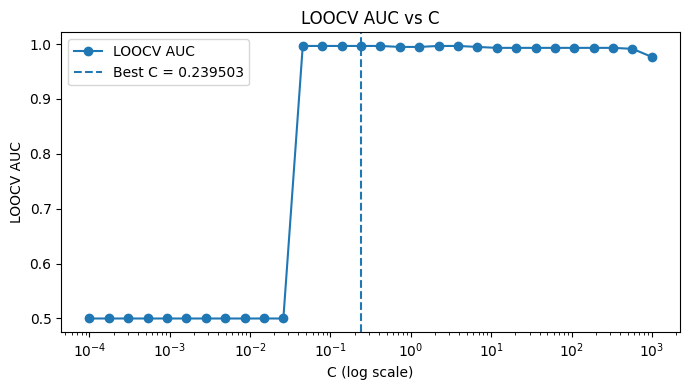


Best C: 0.2395026619987486
  loocv_auc: 0.9965277777777778
  loocv_accuracy_at_0.5: 0.9666666666666667
  n_rows: 60
  n_features: 14
  n_positive: 12
  n_negative: 48
  C: 0.2395026619987486


In [10]:
DROP_IDX = 6
tune_input = combined_df.drop(index=DROP_IDX).reset_index(drop=True)

c_tuning = tune_C_loocv_logistic(
    df=tune_input,
    feature_cols=FEATURES,
    label_col='is_insider',
    C_grid=np.logspace(-4, 3, 30),
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    plot=True,
)

behavior_model = c_tuning['best_model']
print(f"\nBest C: {c_tuning['best_C']}")
for k, v in c_tuning['best_result']['metrics'].items():
    print(f'  {k}: {v}')

## Hunt for more insiders

`check_candidate(wallet, slug)` plots the wallet's trades on the market's YES-price history and prints the model's predicted insider probability. New markets get fetched + cached on first call; pass `force_refresh=True` to re-fetch a market whose events may have changed since the last cache.

In [7]:
def check_candidate(wallet: str, slug: str, force_refresh: bool = False) -> float:
    """Score one (wallet, market) pair and plot the wallet's trade history."""
    wallet = wallet.lower()
    data = load_or_fetch_market(slug, force_refresh=force_refresh)
    market = data['market']
    history = data['history']
    user_trades = data['parsed']['wallet_trades'].get(wallet, [])

    row_df = pd.DataFrame([build_feature_row(wallet, slug)])
    row_df = impute_feature_only_df(row_df, FEATURES)
    #prob = float(behavior_model.predict_proba(row_df[FEATURES])[:, 1][0])

    trades_df = normalize_trades_to_yes_df(
        user_trades,
        yes_token=market.yes_token_id,
        no_token=market.no_token_id,
    )
    mapped_df = map_trades_to_history(trades_df, history)
    plot_user_on_history(mapped_df, history)


## Run a candidate

Edit `WALLET` and `SLUG` and re-run the cell.

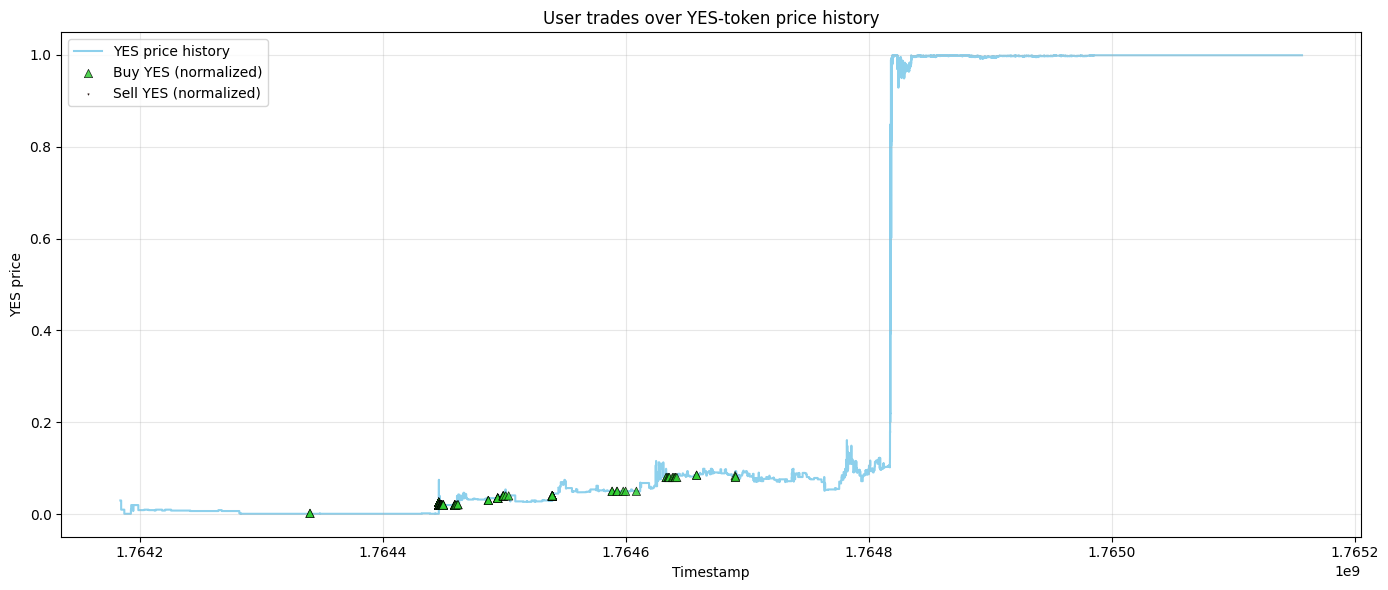


Predicted probability of being an insider: 0.9722


0.9721759780287578

In [12]:
WALLET = '0xee50a31c3f5a7c77824b12a941a54388a2827ed6'
SLUG = 'will-d4vd-be-the-1-searched-person-on-google-this-year'

check_candidate(WALLET, SLUG)

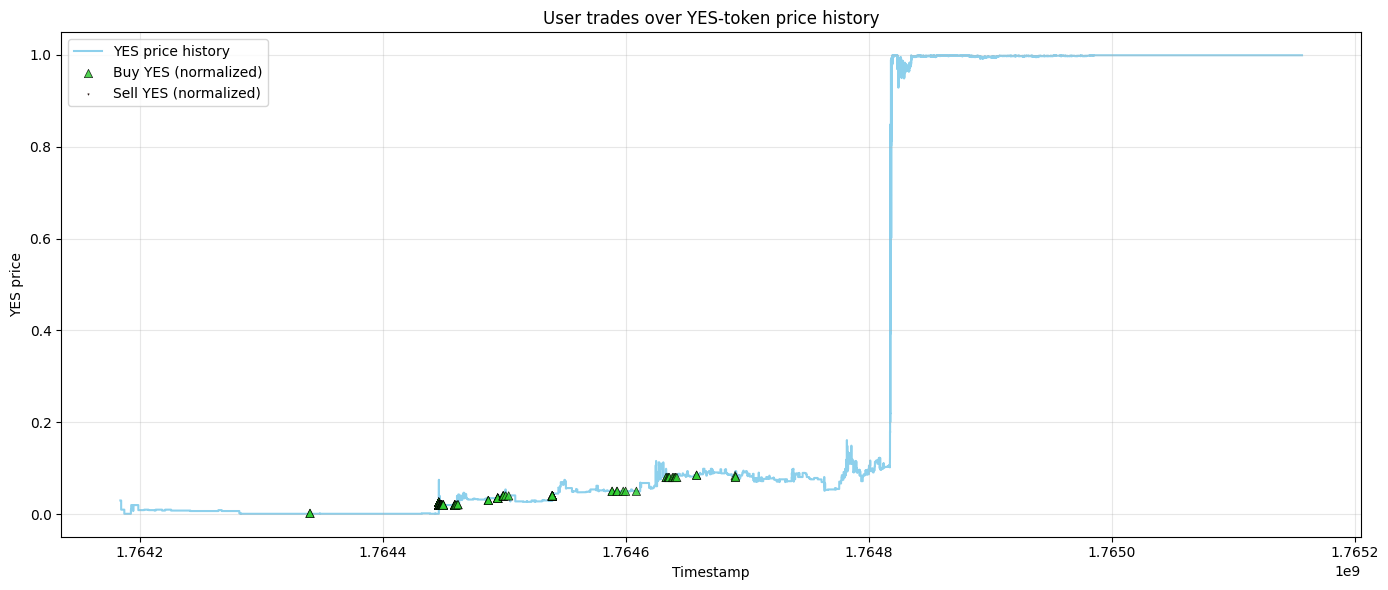


Predicted probability of being an insider: 0.9722


0.9721759780287578

In [13]:
WALLET = '0xee50a31c3f5a7c77824b12a941a54388a2827ed6'
SLUG = 'will-d4vd-be-the-1-searched-person-on-google-this-year'

check_candidate(WALLET, SLUG)

Fetching market: confirmed-case-of-hantavirus-in-us-by-may-15
[polycluster] get_orderfilled_events: 2 token(s), window=[1778170130, 1778683329] (513199s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 0 rows in 0.2s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 0 rows in 0.2s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 0 rows in 0.2s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 0 rows in 0.2s
[polycluster] get_orderfilled_events: done, 0 unique rows in 0.7s
[polycluster] subgraph returned 0 events; falling back to Polymarket Data API
[data-api] fetched 500 trades (offset=0)
[data-api] fetched 1000 trades (offset=500)
[data-api] fetched 1500 trades (offset=1000)
[data-api] fetched 2000 trades (offset=1500)
[data-api] fetched 2500 trades (offset=2000)
[data-api] fetched 300

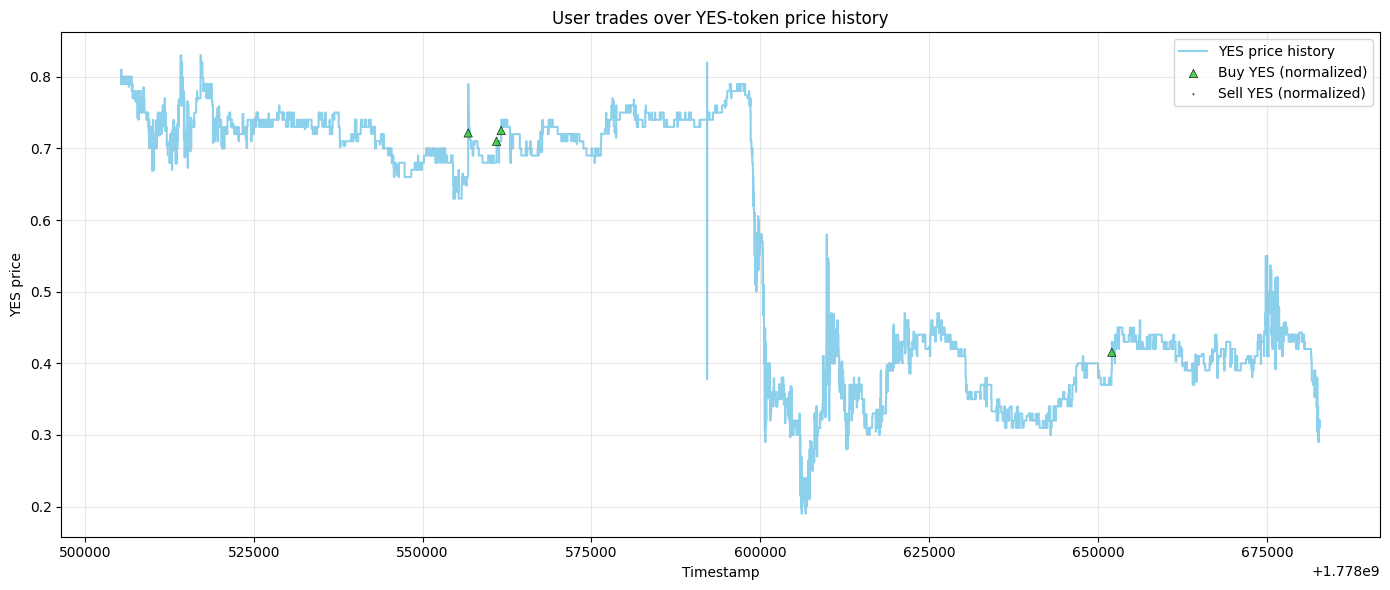


Predicted probability of being an insider: 0.0274


0.02737778115806011

In [ ]:
WALLET = '0x44c1dfe43260c94ed4f1d00de2e1f80fb113ebc1'
SLUG = 'confirmed-case-of-hantavirus-in-us-by-may-15'

check_candidate(WALLET, SLUG)

In [20]:
import requests

def list_market_slugs(event_slug: str) -> None:
    """Print every market slug under a Polymarket event."""
    events = requests.get(
        "https://gamma-api.polymarket.com/events",
        params={"slug": event_slug},
    ).json()
    if not events:
        print(f"No event found for slug: {event_slug}")
        return
    for event in events:
        print(f"Event: {event['slug']}")
        for m in event.get("markets", []):
            print(f"  slug: {m['slug']}")
            print(f"    Q:  {m.get('question')}")
            print(f"    closed={m.get('closed')}  vol=${float(m.get('volume', 0)):,.0f}")
            print()

list_market_slugs("will-aztec-launch-a-token-in-2025")

Event: will-aztec-launch-a-token-in-2025
  slug: will-aztec-launch-a-token-in-2025
    Q:  Will Aztec launch a token in 2025?
    closed=True  vol=$956,046

  slug: will-aztec-launch-a-token-by-march-31-2026
    Q:  Will Aztec launch a token by March 31, 2026?
    closed=True  vol=$249,120



Fetching market: will-aztec-launch-a-token-in-2025
[polycluster] get_orderfilled_events: 2 token(s), window=[1760907815, 1767258055] (6350240s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 1772 rows in 12.7s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 2794 rows in 17.5s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 1324 rows in 8.4s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 2132 rows in 15.3s
[polycluster] get_orderfilled_events: done, 8022 unique rows in 54.0s
  cached: events=8022, wallets=1255


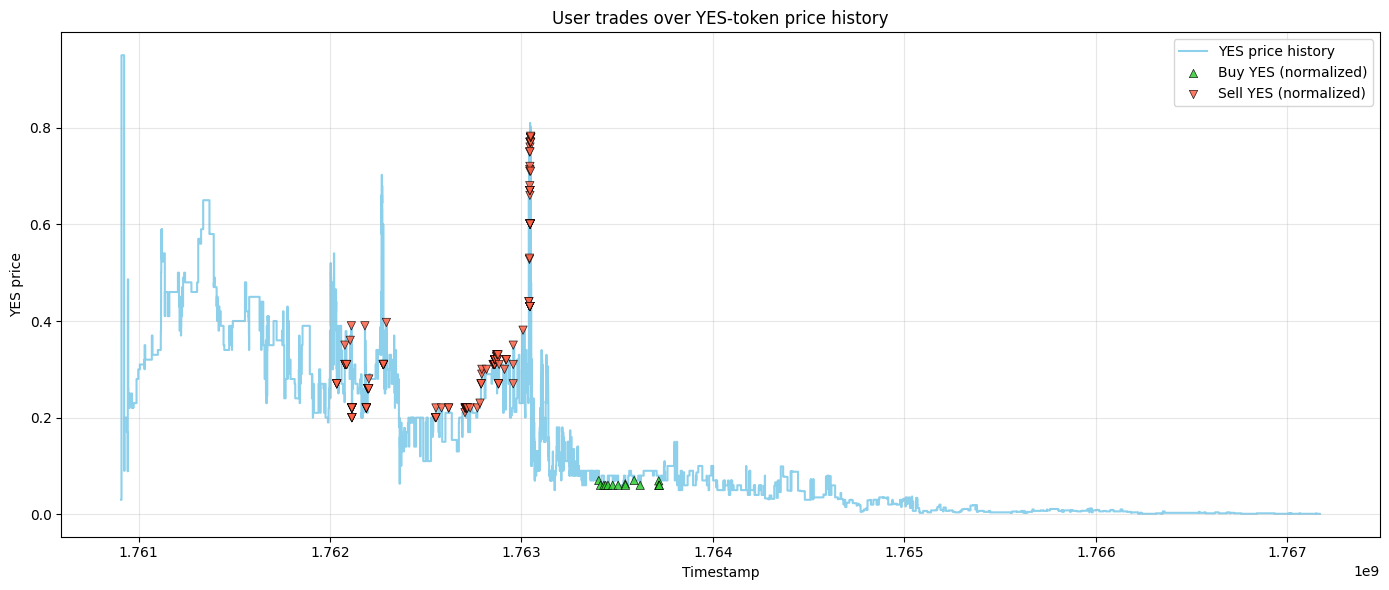


Predicted probability of being an insider: 0.7338


0.7337521114465616

In [22]:
WALLET = '0x63c247f9e2722273120a2c4a4c0f01b658022c46'
SLUG = 'will-aztec-launch-a-token-in-2025'

check_candidate(WALLET, SLUG)

Fetching market: israel-strikes-iran-by-march-31-2026
[polycluster] get_orderfilled_events: 2 token(s), window=[1764635808, 1772270091] (7634283s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 10103 rows in 69.1s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 13568 rows in 98.9s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 7110 rows in 46.3s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 10953 rows in 76.4s
[polycluster] get_orderfilled_events: done, 41734 unique rows in 291.1s
  cached: events=41734, wallets=4610


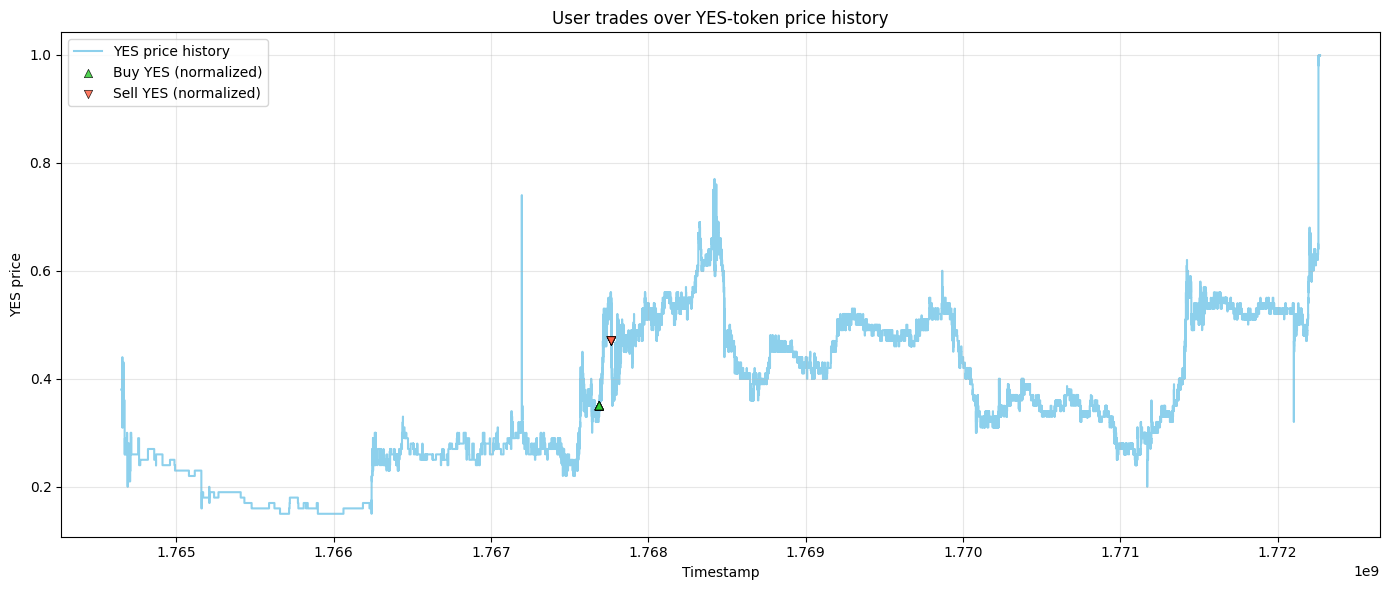


Predicted probability of being an insider: 0.2241


0.22407617565096805

In [ ]:
WALLET = '0x0afc7ce56285bde1fbe3a75efaffdfc86d6530b2' #confirmed insider, air force general in israel army
SLUG = 'israel-strikes-iran-by-march-31-2026'

check_candidate(WALLET, SLUG)

Fetching market: israel-strikes-iran-by-january-31-2026-894-994-453
[polycluster] get_orderfilled_events: 2 token(s), window=[1766424503, 1769947494] (3522991s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 32025 rows in 206.8s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 42555 rows in 321.4s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[INFO] timeout on [1766424503, 1769947494] for side=maker; splitting into [1766424503, 1768185998] and [1768185999, 1769947494]
[polycluster]   (3/4) token 2/2 side=maker: 26088 rows in 168.0s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[INFO] timeout on [1766424503, 1769947494] for side=taker; splitting into [1766424503, 1768185998] and [1768185999, 1769947494]
[INFO] timeout on [1766424503, 1768185998] for side=taker; splitting into [1766424503, 1767305250] and [1767305251, 1768185998]
[INFO] timeout on [1766424503, 17673

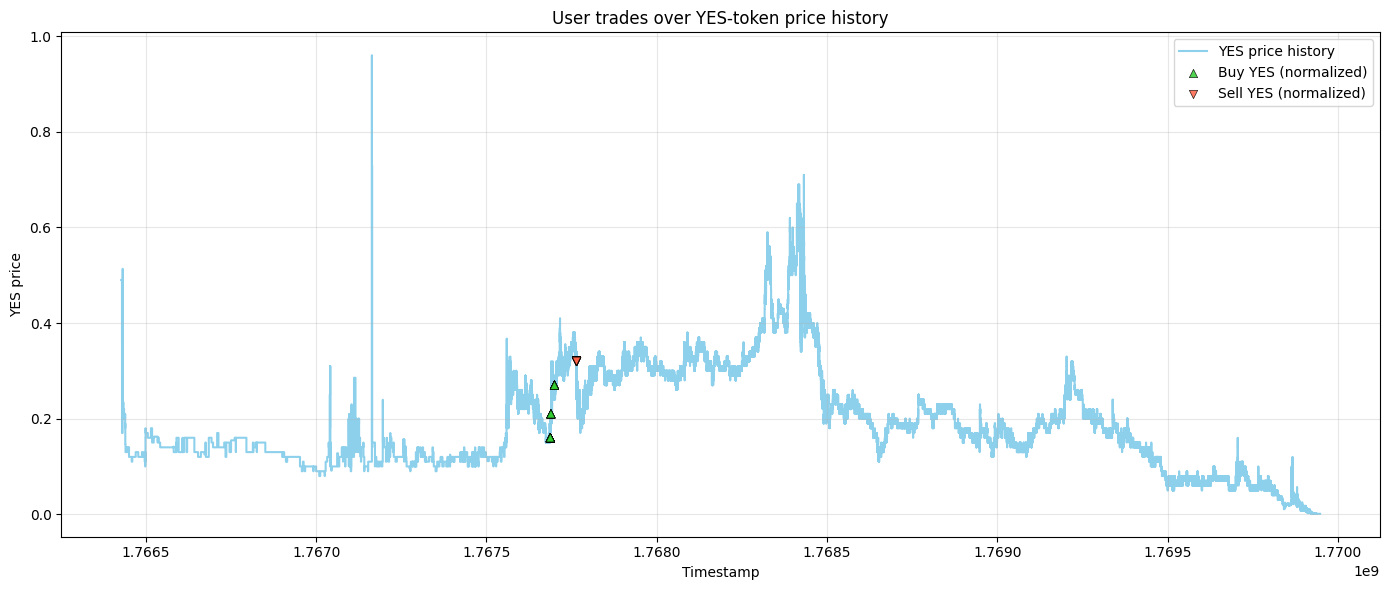


Predicted probability of being an insider: 0.2241


0.22407602881371524

In [25]:
#israel-strikes-iran-by-january-31-2026-894-994-453
WALLET = '0x0afc7ce56285bde1fbe3a75efaffdfc86d6530b2' #confirmed insider, air force general in israel army
SLUG = 'israel-strikes-iran-by-january-31-2026-894-994-453'

check_candidate(WALLET, SLUG)


Fetching market: will-draftkings-launch-a-prediction-market-in-2025
[polycluster] get_orderfilled_events: 2 token(s), window=[1759959228, 1766157604] (6198376s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 3330 rows in 25.9s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1759959228, 1766157604] for side=taker; splitting into [1759959228, 1763058416] and [1763058417, 1766157604]
[INFO] timeout on [1759959228, 1763058416] for side=taker; splitting into [1759959228, 1761508822] and [1761508823, 1763058416]
[INFO] timeout on [1759959228, 1761508822] for side=taker; splitting into [1759959228, 1760734025] and [1760734026, 1761508822]
[INFO] timeout on [1759959228, 1760734025] for side=taker; splitting into [1759959228, 1760346626] and [1760346627, 1760734025]
[INFO] timeout on [1759959228, 1760346626] for side=taker; splitting into [1759959228, 1760152927] and [1760152928, 1760346626]
[INFO] timeout on [17660

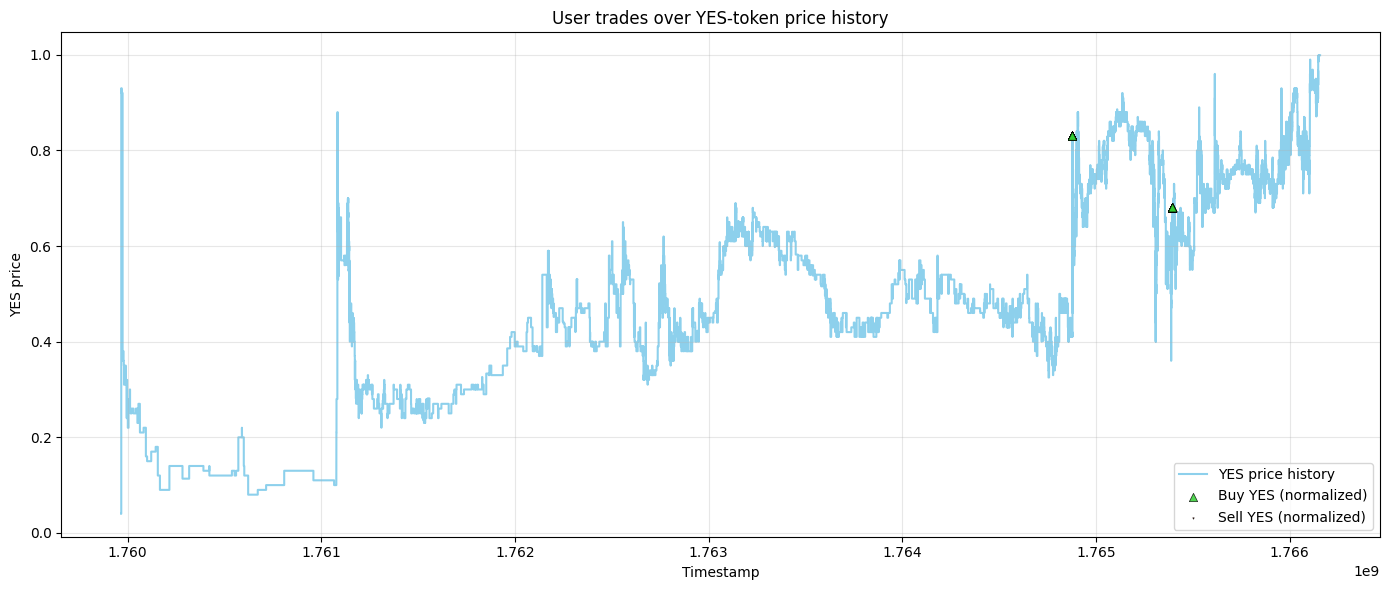


Predicted probability of being an insider: 0.6062


0.6062340774771581

In [27]:
"""0x8dc5fcff363eef19ad5f0bfce9f1fa216d456706""" #will-draftkings-launch-a-prediction-market-in-2025
WALLET = '0x8dc5fcff363eef19ad5f0bfce9f1fa216d456706' 
SLUG = 'will-draftkings-launch-a-prediction-market-in-2025'

check_candidate(WALLET, SLUG)

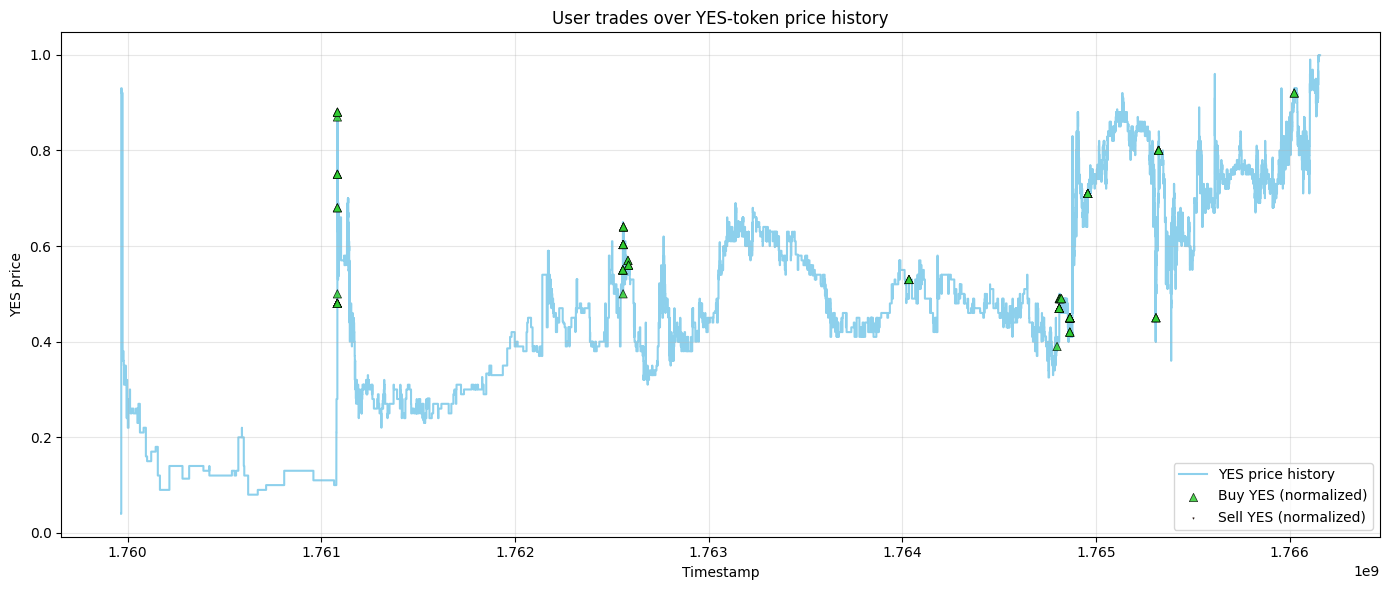


Predicted probability of being an insider: 0.7188


0.7187949672077459

In [28]:
"""0x55ea982cebff271722419595e0659ef297b48d7c""" #will-draftkings-launch-a-prediction-market-in-2025
WALLET = '0x55ea982cebff271722419595e0659ef297b48d7c' 
SLUG = 'will-draftkings-launch-a-prediction-market-in-2025'

check_candidate(WALLET, SLUG)

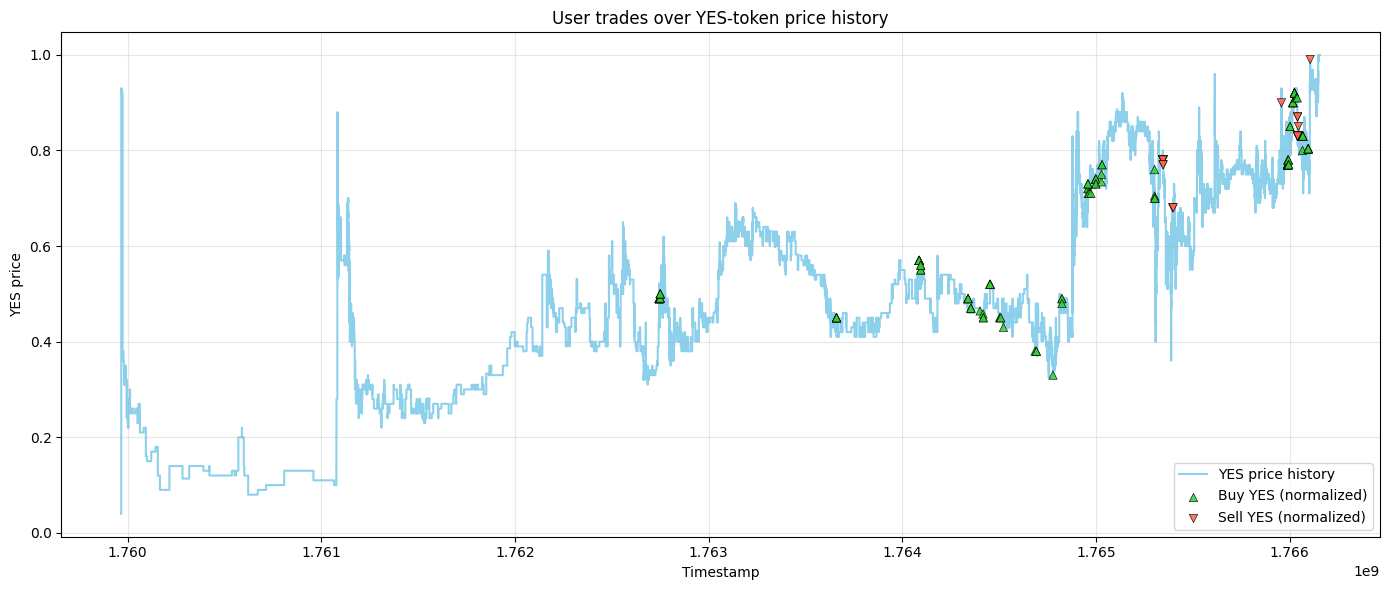


Predicted probability of being an insider: 0.2387


0.23870998197129428

In [29]:
"""0xbd810a483eb846da535405a442532f86dcfe1f7f""" ##will-draftkings-launch-a-prediction-market-in-2025
WALLET = '0xbd810a483eb846da535405a442532f86dcfe1f7f' 
SLUG = 'will-draftkings-launch-a-prediction-market-in-2025'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x976685b6e867a0400085b1273309e84cd0fc627c""" #nothing-ever-happens-microstrategy 
#microstrategy-announces-1000-btc-purchase-december-2-8 
#microstrategy-sell-any-bitcoin-in-2025 
#will-microstrategy-announce-holding-650k-btc-by-november-30


Fetching market: nothing-ever-happens-microstrategy
[polycluster] get_orderfilled_events: 2 token(s), window=[1767728419, 1773672449] (5944030s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 3597 rows in 28.1s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 5870 rows in 43.3s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 2849 rows in 23.3s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 4916 rows in 36.3s
[polycluster] get_orderfilled_events: done, 17232 unique rows in 131.1s
  cached: events=17232, wallets=2368


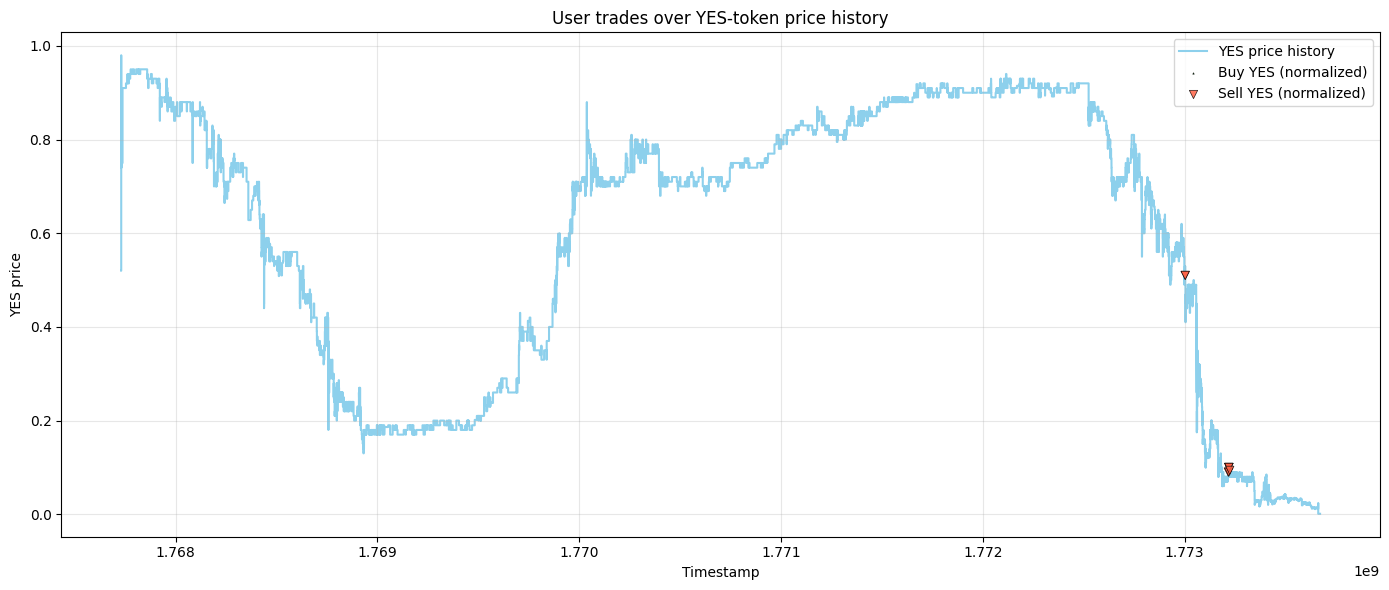


Predicted probability of being an insider: 0.7778


0.7778170720423603

In [30]:
WALLET = '0x976685b6e867a0400085b1273309e84cd0fc627c' 
SLUG = 'nothing-ever-happens-microstrategy'

check_candidate(WALLET, SLUG)

Fetching market: microstrategy-announces-1000-btc-purchase-december-2-8
[polycluster] get_orderfilled_events: 2 token(s), window=[1764567336, 1765206355] (639019s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 1563 rows in 12.3s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1764567336, 1765206355] for side=taker; splitting into [1764567336, 1764886845] and [1764886846, 1765206355]
[INFO] timeout on [1764567336, 1764886845] for side=taker; splitting into [1764567336, 1764727090] and [1764727091, 1764886845]
[polycluster]   (2/4) token 1/2 side=taker: 4203 rows in 30.7s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 704 rows in 5.9s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[INFO] timeout on [1764567336, 1765206355] for side=taker; splitting into [1764567336, 1764886845] and [1764886846, 1765206355]
[polycluster]   (4/4) token 2/2 side=take

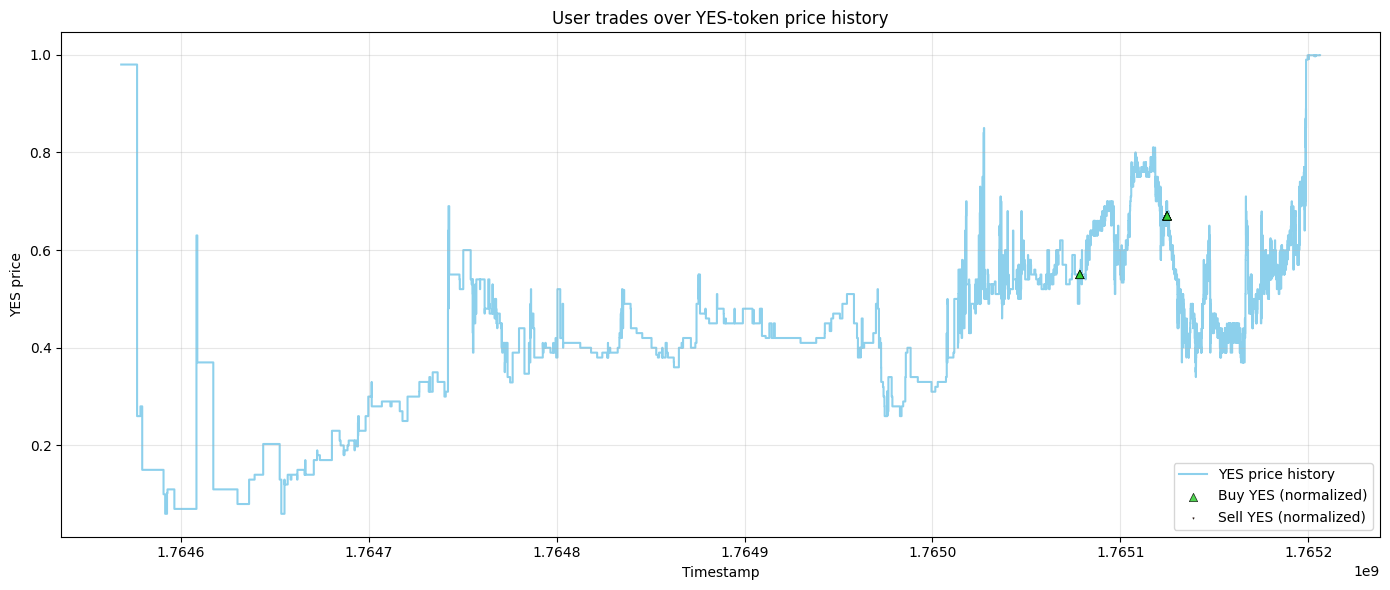


Predicted probability of being an insider: 0.7184


0.7183601493848794

In [31]:
WALLET = '0x976685b6e867a0400085b1273309e84cd0fc627c' 
SLUG = 'microstrategy-announces-1000-btc-purchase-december-2-8'

check_candidate(WALLET, SLUG)

Fetching market: microstrategy-sell-any-bitcoin-in-2025
[polycluster] get_orderfilled_events: 2 token(s), window=[1735671022, 1767586945] (31915923s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 5435 rows in 36.0s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1735671022, 1767586945] for side=taker; splitting into [1735671022, 1751628983] and [1751628984, 1767586945]
[INFO] timeout on [1735671022, 1751628983] for side=taker; splitting into [1735671022, 1743650002] and [1743650003, 1751628983]
[INFO] timeout on [1735671022, 1743650002] for side=taker; splitting into [1735671022, 1739660512] and [1739660513, 1743650002]
[polycluster]   (2/4) token 1/2 side=taker: 9775 rows in 79.2s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 7428 rows in 51.5s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 11987 row

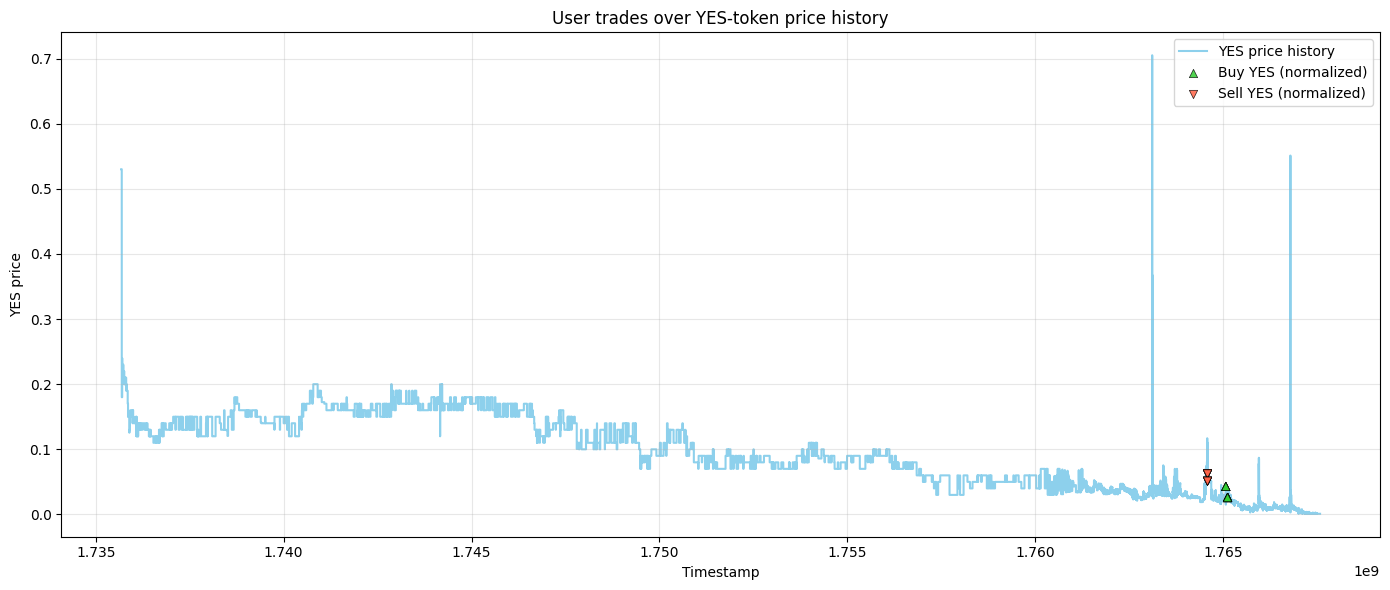


Predicted probability of being an insider: 0.2241


0.22410175928529313

In [32]:
WALLET = '0x976685b6e867a0400085b1273309e84cd0fc627c' 
SLUG = 'microstrategy-sell-any-bitcoin-in-2025'

check_candidate(WALLET, SLUG)

Fetching market: will-microstrategy-announce-holding-650k-btc-by-november-30
[polycluster] get_orderfilled_events: 2 token(s), window=[1761950908, 1764573706] (2622798s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 1361 rows in 8.2s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1763846292, 1763851414] for side=taker; splitting into [1763846292, 1763848853] and [1763848854, 1763851414]
[INFO] timeout on [1763851415, 1763856536] for side=taker; splitting into [1763851415, 1763853975] and [1763853976, 1763856536]
[polycluster]   (2/4) token 1/2 side=taker: 2485 rows in 28.2s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 1152 rows in 7.4s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 2077 rows in 12.8s
[polycluster] get_orderfilled_events: done, 7075 unique rows in 56.6s
  cached: events=7075, wallets

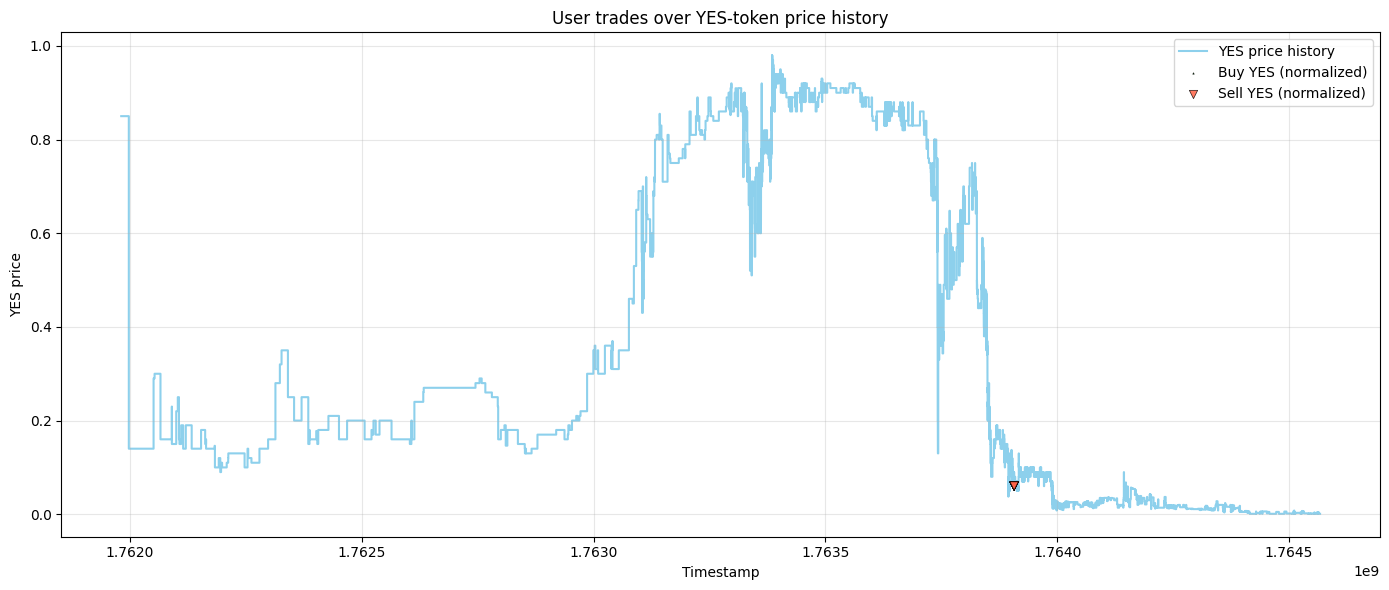


Predicted probability of being an insider: 0.2817


0.2817349557242626

In [33]:
WALLET = '0x976685b6e867a0400085b1273309e84cd0fc627c' 
SLUG = 'will-microstrategy-announce-holding-650k-btc-by-november-30'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x5d55e3cf7a108e462186bedb04e090d4cd033bdf""" 
#will-microstrategy-announce-a-bitcoin-purchase-december-16-22 
#microstrategy-announces-1000-btc-purchase-december-2-8


Fetching market: will-microstrategy-announce-a-bitcoin-purchase-december-16-22
[polycluster] get_orderfilled_events: 2 token(s), window=[1765776631, 1766473895] (697264s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[INFO] timeout on [1765776631, 1766473895] for side=maker; splitting into [1765776631, 1766125263] and [1766125264, 1766473895]
[INFO] timeout on [1766125264, 1766473895] for side=maker; splitting into [1766125264, 1766299579] and [1766299580, 1766473895]
[polycluster]   (1/4) token 1/2 side=maker: 670 rows in 8.3s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1765776631, 1766473895] for side=taker; splitting into [1765776631, 1766125263] and [1766125264, 1766473895]
[polycluster]   (2/4) token 1/2 side=taker: 1883 rows in 16.7s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 304 rows in 1.7s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side

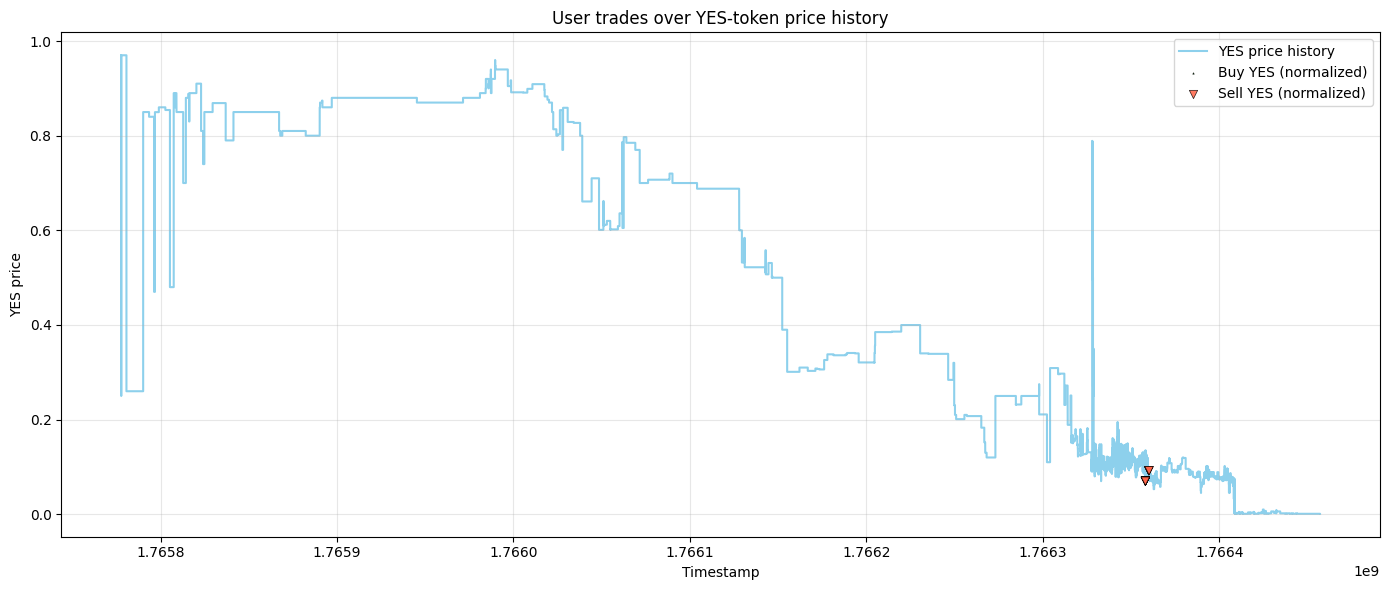


Predicted probability of being an insider: 0.2969


0.29689381423353967

In [34]:
WALLET = '0x5d55e3cf7a108e462186bedb04e090d4cd033bdf' 
SLUG = 'will-microstrategy-announce-a-bitcoin-purchase-december-16-22'

check_candidate(WALLET, SLUG)

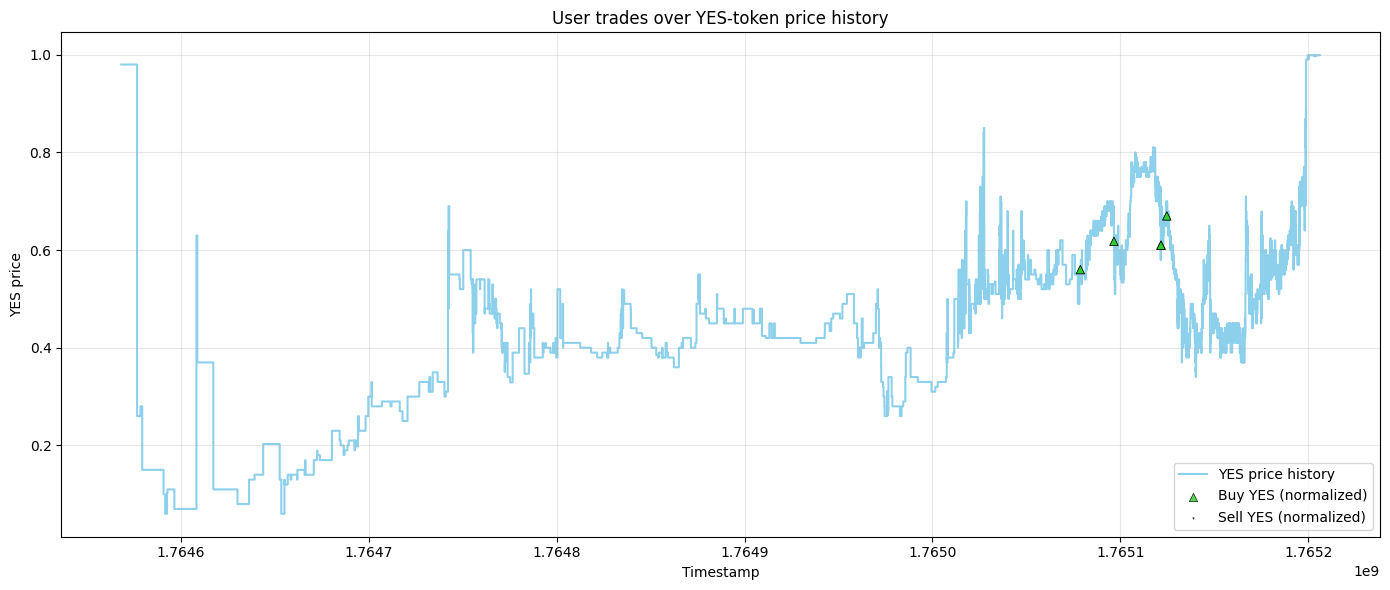


Predicted probability of being an insider: 0.7258


0.7257771317453559

In [35]:
WALLET = '0x5d55e3cf7a108e462186bedb04e090d4cd033bdf' 
SLUG = 'microstrategy-announces-1000-btc-purchase-december-2-8'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x567500e942fa8ea41bea3272014565d6466959bc""" 
#microstrategy-announces-1000-btc-purchase-november-11-17 
#will-microstrategy-announce-holding-650k-btc-by-november-30 
#microstrategy-announces-1000-btc-purchase-december-2-8

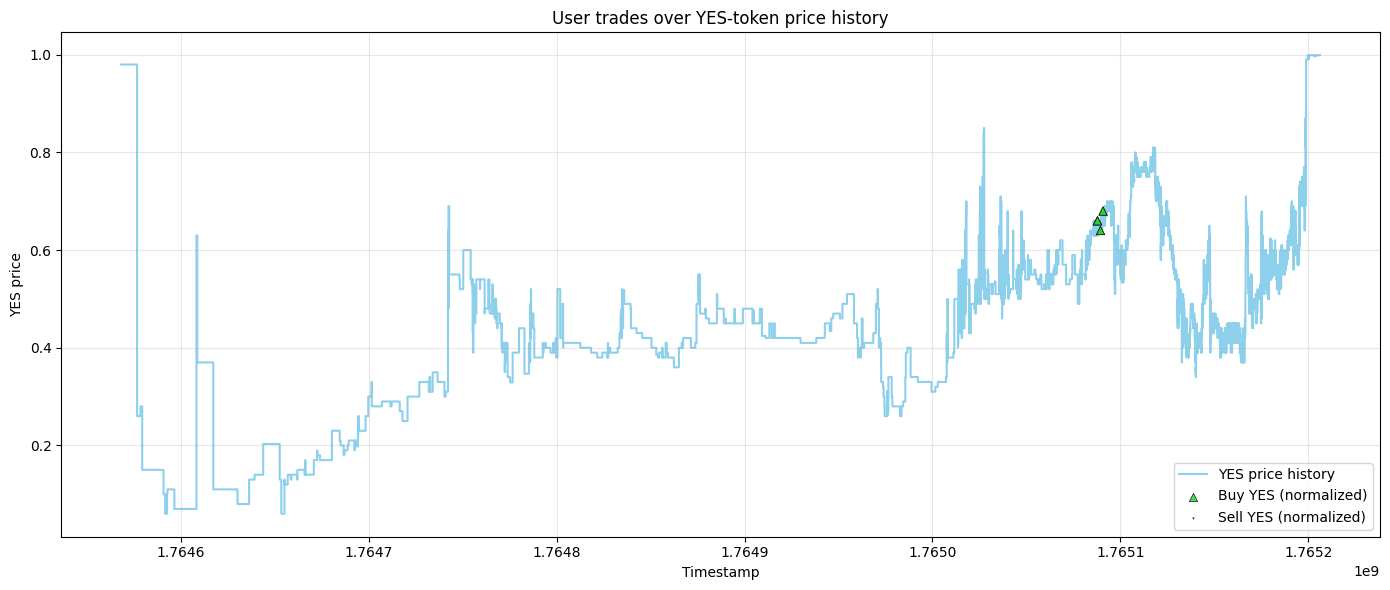


Predicted probability of being an insider: 0.6259


0.625882281344322

In [36]:
WALLET = '0x567500e942fa8ea41bea3272014565d6466959bc' 
SLUG = 'microstrategy-announces-1000-btc-purchase-december-2-8'

check_candidate(WALLET, SLUG)

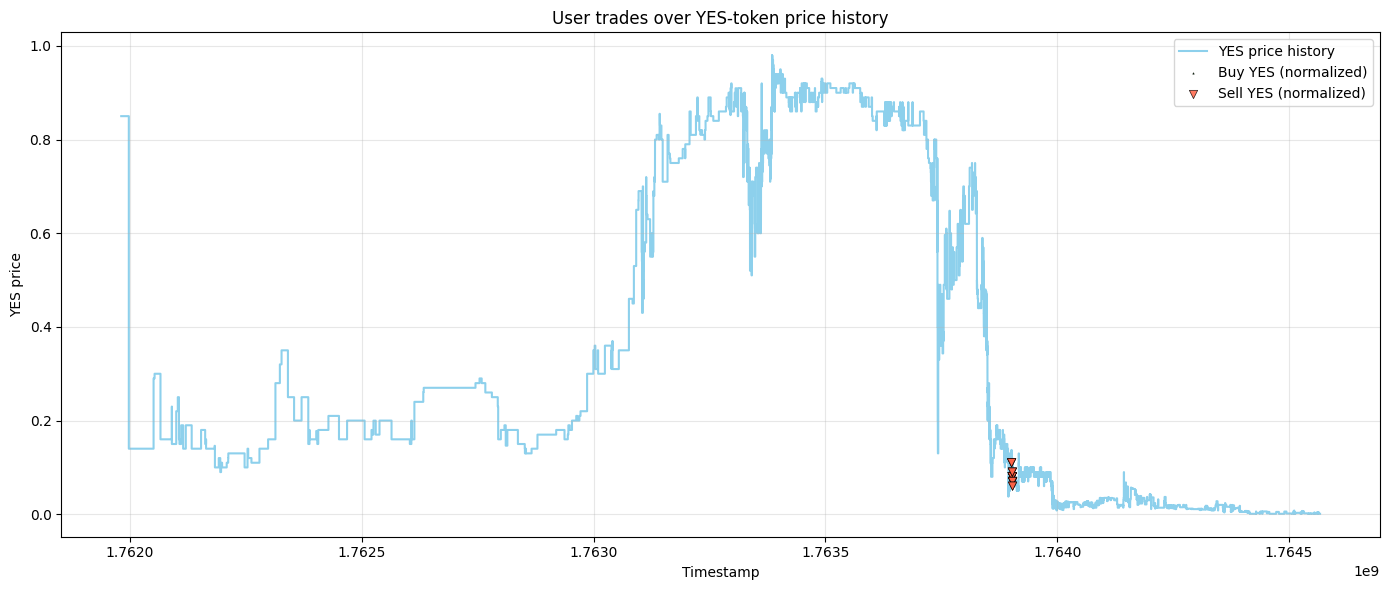


Predicted probability of being an insider: 0.3133


0.31330505019748794

In [37]:
WALLET = '0x567500e942fa8ea41bea3272014565d6466959bc' 
SLUG = 'will-microstrategy-announce-holding-650k-btc-by-november-30'

check_candidate(WALLET, SLUG)

Fetching market: microstrategy-announces-1000-btc-purchase-november-11-17
[polycluster] get_orderfilled_events: 2 token(s), window=[1762752935, 1763393855] (640920s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 439 rows in 5.8s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 1097 rows in 6.6s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 454 rows in 3.3s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 1014 rows in 6.7s
[polycluster] get_orderfilled_events: done, 3004 unique rows in 22.4s
  cached: events=3004, wallets=566


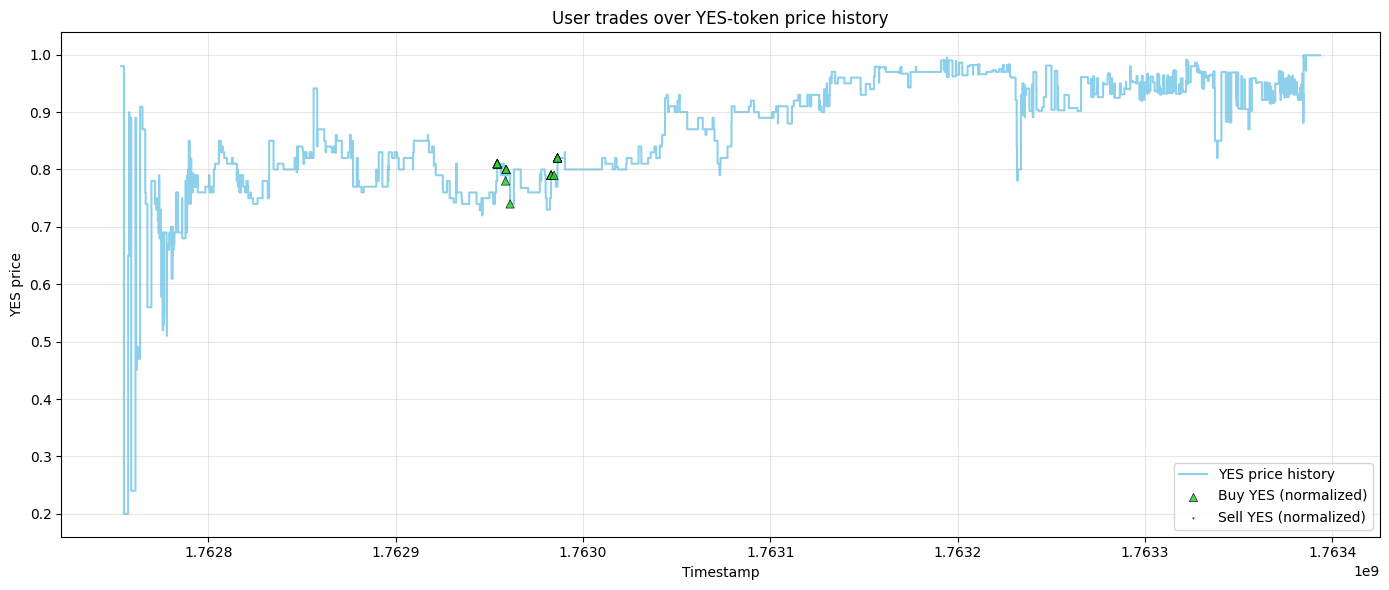


Predicted probability of being an insider: 0.4819


0.48187936029943057

In [38]:
WALLET = '0x567500e942fa8ea41bea3272014565d6466959bc' 
SLUG = 'microstrategy-announces-1000-btc-purchase-november-11-17'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x6e1a7bd753e97eaa367f45f4229d82f176475633""" 
#microstrategy-announces-1000-btc-purchase-december-2-8 
#will-microstrategy-purchase-bitcoin-july-1-7

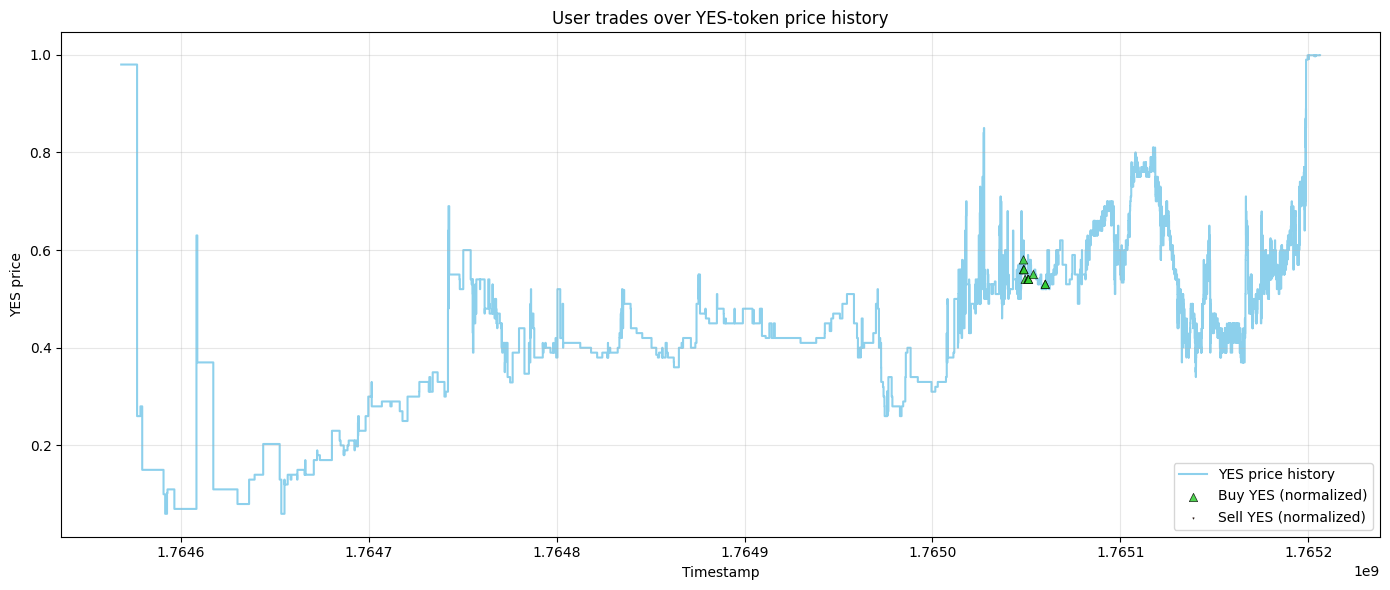


Predicted probability of being an insider: 0.7746


0.7745732880426635

In [39]:
WALLET = '0x6e1a7bd753e97eaa367f45f4229d82f176475633' 
SLUG = 'microstrategy-announces-1000-btc-purchase-december-2-8'

check_candidate(WALLET, SLUG)

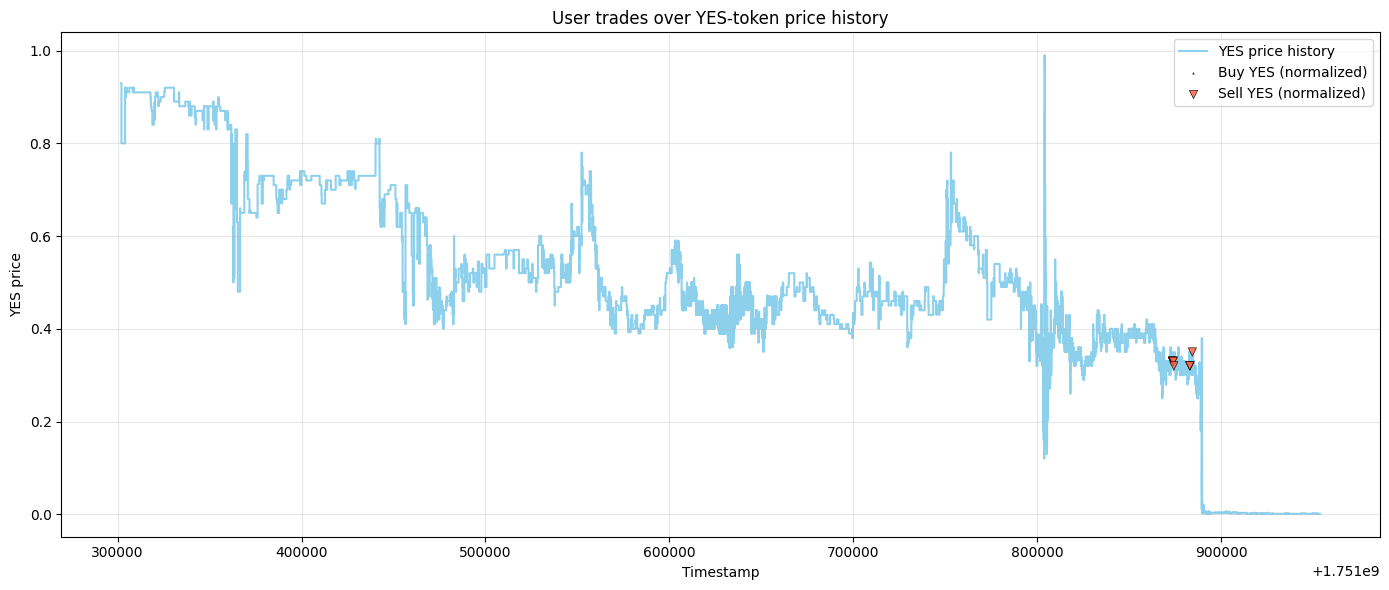


Predicted probability of being an insider: 0.6046


0.6046464967311456

In [49]:
WALLET = '0x6e1a7bd753e97eaa367f45f4229d82f176475633' 
SLUG = 'will-microstrategy-purchase-bitcoin-july-1-7'

check_candidate(WALLET, SLUG)

In [ ]:
"""0xaab69d14e74adf2e46459af9a6b512dbedd2f297""" 
#will-microstrategy-announce-a-bitcoin-purchase-december-16-22 
#microstrategy-announces-1000-btc-purchase-december-2-8 
#will-microstrategy-purchase-bitcoin-july-1-7 
#will-microstrategy-hold-620k-btc-before-august

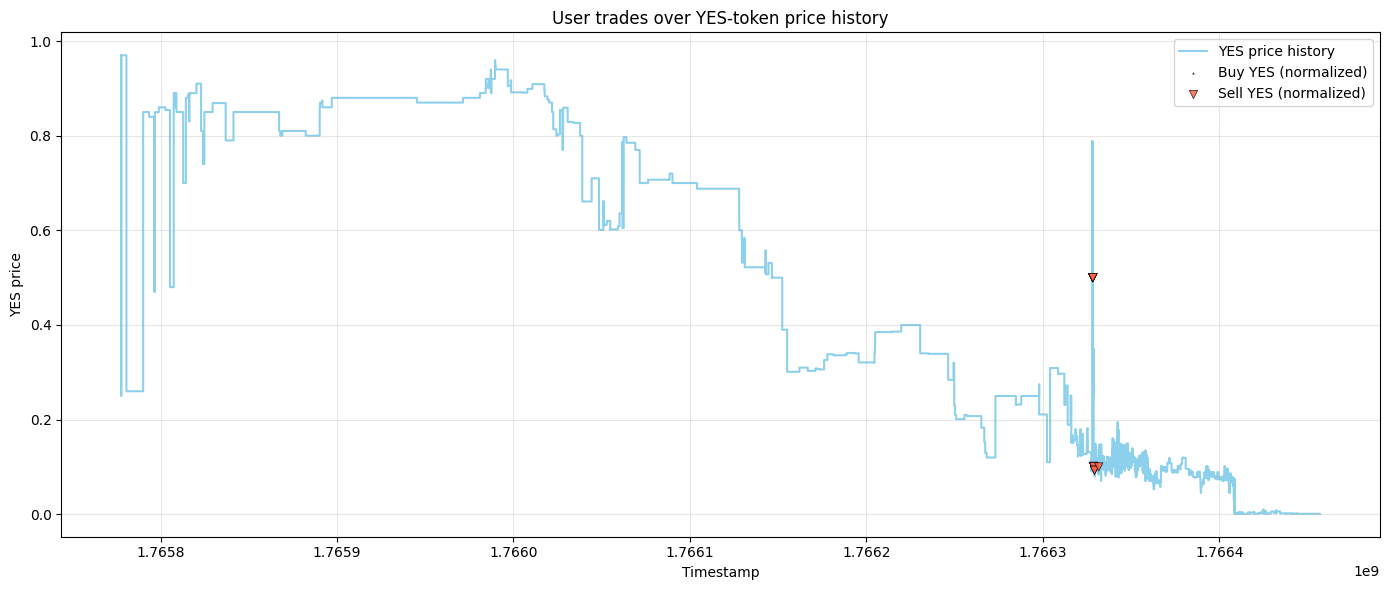


Predicted probability of being an insider: 0.4450


0.4450189374845412

In [41]:
WALLET = '0xaab69d14e74adf2e46459af9a6b512dbedd2f297' 
SLUG = 'will-microstrategy-announce-a-bitcoin-purchase-december-16-22'

check_candidate(WALLET, SLUG)

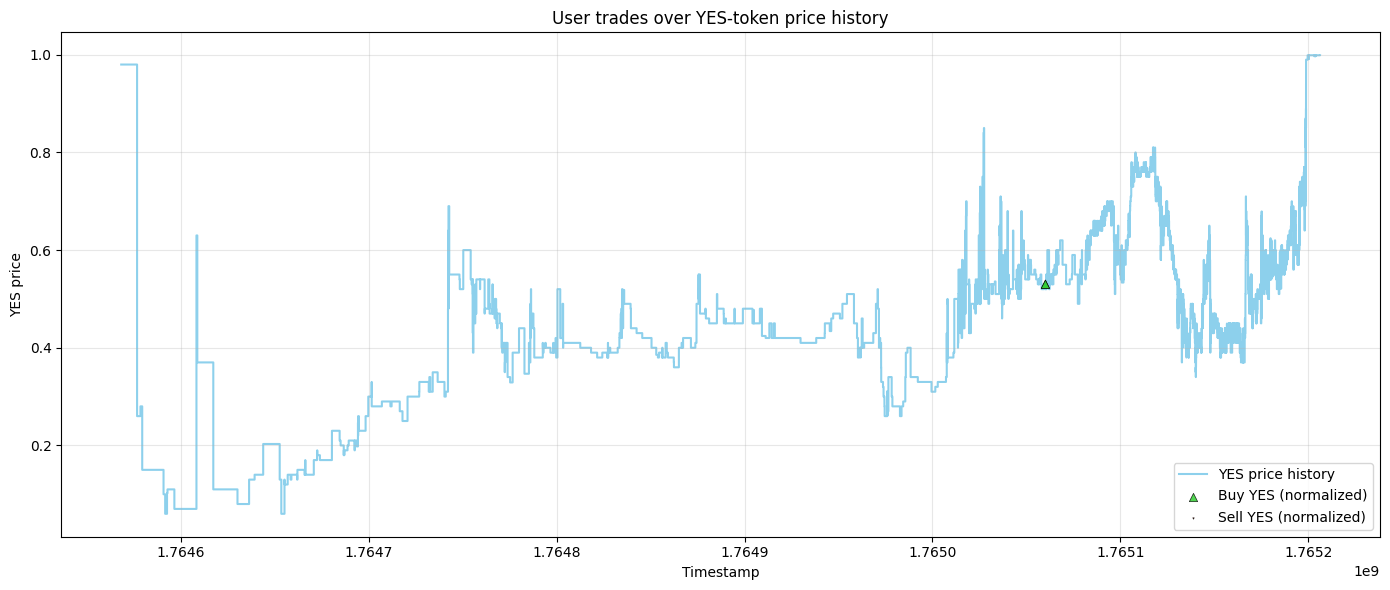


Predicted probability of being an insider: 0.7831


0.7831349833061665

In [42]:
WALLET = '0xaab69d14e74adf2e46459af9a6b512dbedd2f297' 
SLUG = 'microstrategy-announces-1000-btc-purchase-december-2-8'

check_candidate(WALLET, SLUG)

Fetching market: will-microstrategy-purchase-bitcoin-july-1-7
[polycluster] get_orderfilled_events: 2 token(s), window=[1751301300, 1751954435] (653135s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 15596 rows in 122.2s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1751627868, 1751648278] for side=taker; splitting into [1751627868, 1751638073] and [1751638074, 1751648278]
[polycluster]   (2/4) token 1/2 side=taker: 17746 rows in 137.4s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[INFO] timeout on [1751301300, 1751954435] for side=maker; splitting into [1751301300, 1751627867] and [1751627868, 1751954435]
[polycluster]   (3/4) token 2/2 side=maker: 2934 rows in 27.4s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 4855 rows in 37.8s
[polycluster] get_orderfilled_events: done, 41131 unique rows in 325.3s
  cached: events=41131, wallets=8882


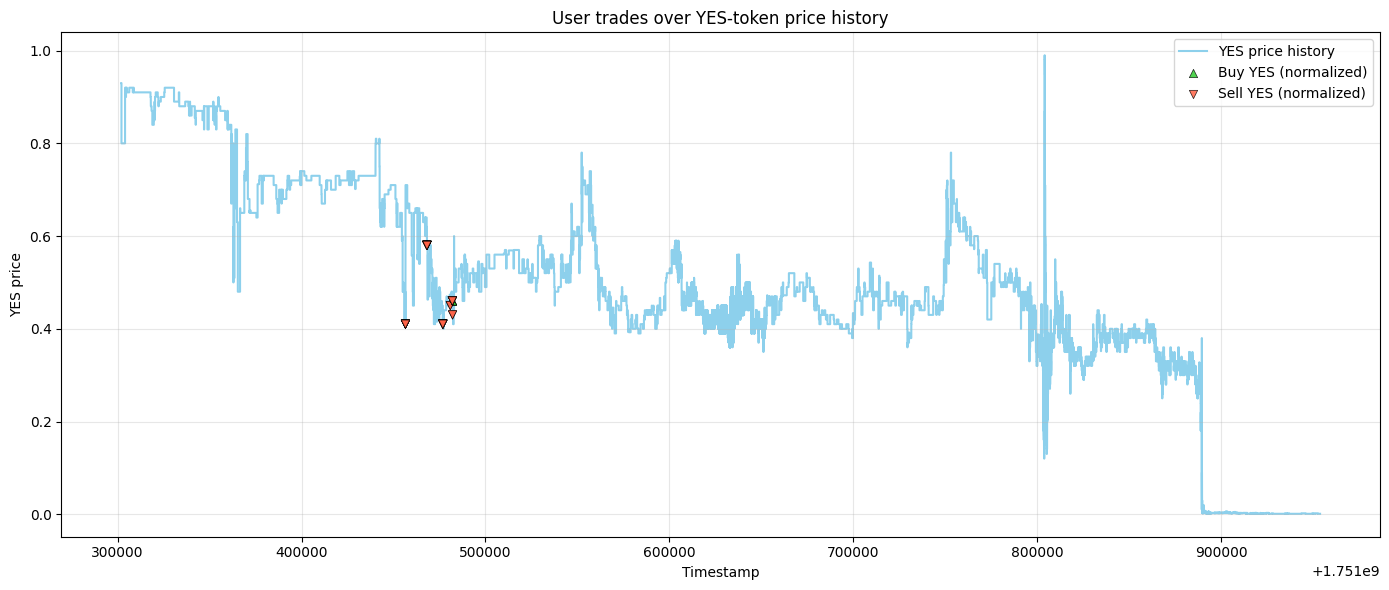


Predicted probability of being an insider: 0.7489


0.7488761545082112

In [43]:
WALLET = '0xaab69d14e74adf2e46459af9a6b512dbedd2f297' 
SLUG = 'will-microstrategy-purchase-bitcoin-july-1-7'

check_candidate(WALLET, SLUG)

Fetching market: will-microstrategy-hold-620k-btc-before-august
[polycluster] get_orderfilled_events: 2 token(s), window=[1750844511, 1753826875] (2982364s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 954 rows in 6.3s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1750844511, 1753826875] for side=taker; splitting into [1750844511, 1752335693] and [1752335694, 1753826875]
[INFO] timeout on [1750844511, 1752335693] for side=taker; splitting into [1750844511, 1751590102] and [1751590103, 1752335693]
[INFO] timeout on [1753593880, 1753617179] for side=taker; splitting into [1753593880, 1753605529] and [1753605530, 1753617179]
[polycluster]   (2/4) token 1/2 side=taker: 1928 rows in 25.2s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 1158 rows in 8.1s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 2099 

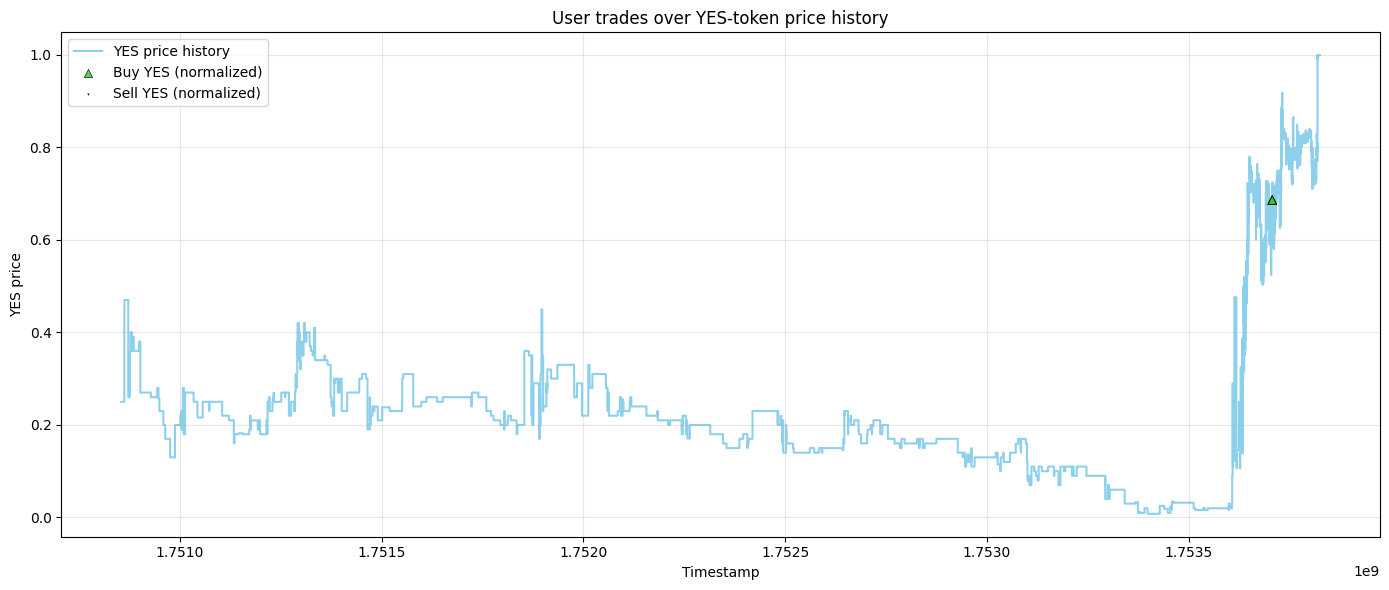


Predicted probability of being an insider: 0.5750


0.5749578510634938

In [44]:
WALLET = '0xaab69d14e74adf2e46459af9a6b512dbedd2f297' 
SLUG = 'will-microstrategy-hold-620k-btc-before-august'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x55ac0f2ea2aa935b88385fe4adb98dd3a60f1023""" 
#will-microstrategy-announce-a-bitcoin-purchase-december-16-22
#will-microstrategy-hold-680k-btc-by-december-31


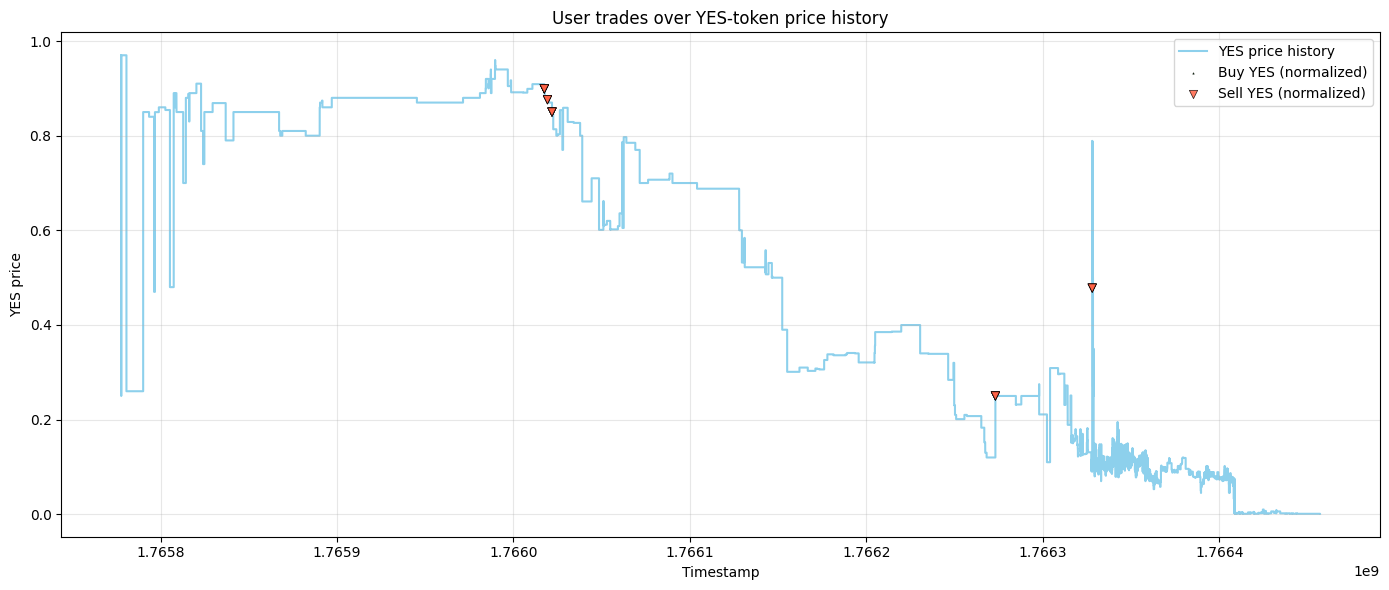


Predicted probability of being an insider: 0.9438


0.9437794297836211

In [45]:
WALLET = '0x55ac0f2ea2aa935b88385fe4adb98dd3a60f1023' 
SLUG = 'will-microstrategy-announce-a-bitcoin-purchase-december-16-22'

check_candidate(WALLET, SLUG)

Fetching market: will-microstrategy-hold-680k-btc-by-december-31
[polycluster] get_orderfilled_events: 2 token(s), window=[1756401807, 1767255825] (10854018s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 1339 rows in 9.8s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 2123 rows in 18.1s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 1115 rows in 7.7s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 1755 rows in 9.9s
[polycluster] get_orderfilled_events: done, 6332 unique rows in 45.6s
  cached: events=6332, wallets=928


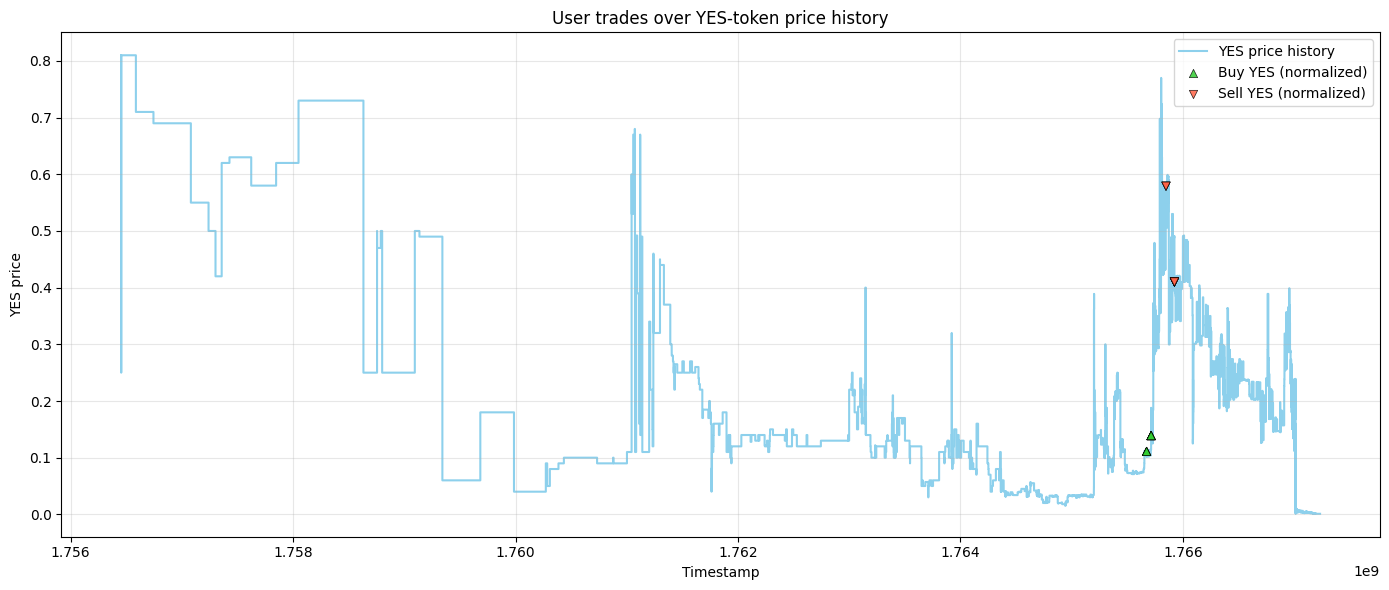


Predicted probability of being an insider: 0.2316


0.23164158189426376

In [46]:
WALLET = '0x55ac0f2ea2aa935b88385fe4adb98dd3a60f1023' 
SLUG = 'will-microstrategy-hold-680k-btc-by-december-31'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x0d832e843cd972ffc9549ed1b6cd6aabf1c49fc7""" 
#microstrategy-announces-1000-btc-purchase-december-2-8

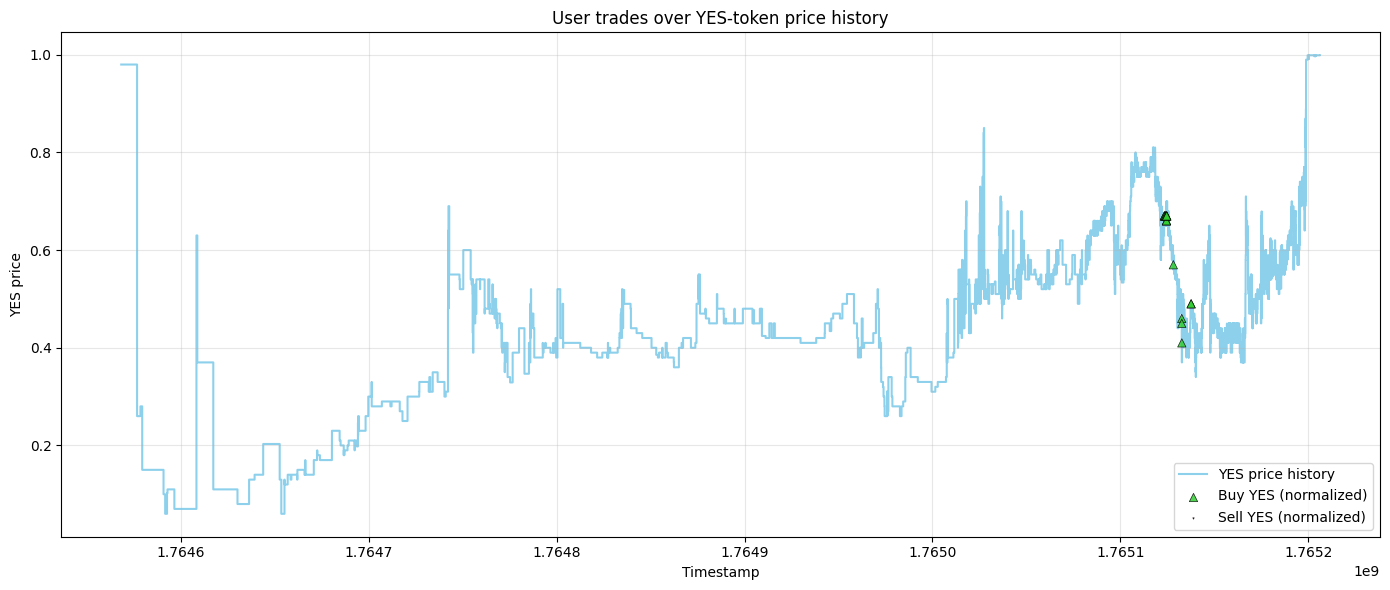


Predicted probability of being an insider: 0.6901


0.6901408418826465

In [47]:
WALLET = '0x0d832e843cd972ffc9549ed1b6cd6aabf1c49fc7' 
SLUG = 'microstrategy-announces-1000-btc-purchase-december-2-8'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x185ffa4bd5bebfd8a463b905137ebd801bb7053c""" #will-stable-launch-a-token-in-2025

Fetching market: will-stable-launch-a-token-in-2025
[polycluster] get_orderfilled_events: 2 token(s), window=[1761071725, 1765227227] (4155502s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 6042 rows in 44.5s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1761071725, 1765227227] for side=taker; splitting into [1761071725, 1763149476] and [1763149477, 1765227227]
[INFO] timeout on [1761071725, 1763149476] for side=taker; splitting into [1761071725, 1762110600] and [1762110601, 1763149476]
[INFO] timeout on [1762439309, 1762443366] for side=taker; splitting into [1762439309, 1762441337] and [1762441338, 1762443366]
[polycluster]   (2/4) token 1/2 side=taker: 12278 rows in 116.3s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 4995 rows in 34.6s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[INFO] timeout on [1761071725, 1765227227] for side=take

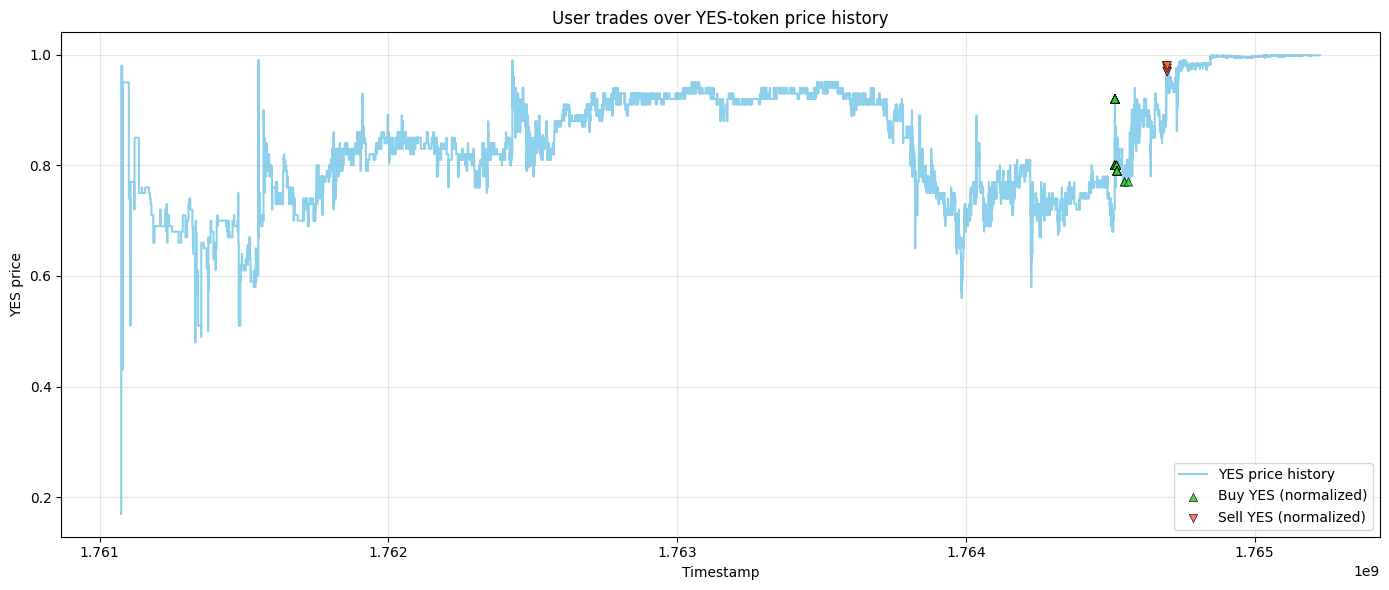


Predicted probability of being an insider: 0.2837


0.28366156577831514

In [48]:
WALLET = '0x185ffa4bd5bebfd8a463b905137ebd801bb7053c' 
SLUG = 'will-stable-launch-a-token-in-2025'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x4b7e367dd40de1d629a09bc414ec7b14e97c8736""" #will-stable-launch-a-token-in-2025

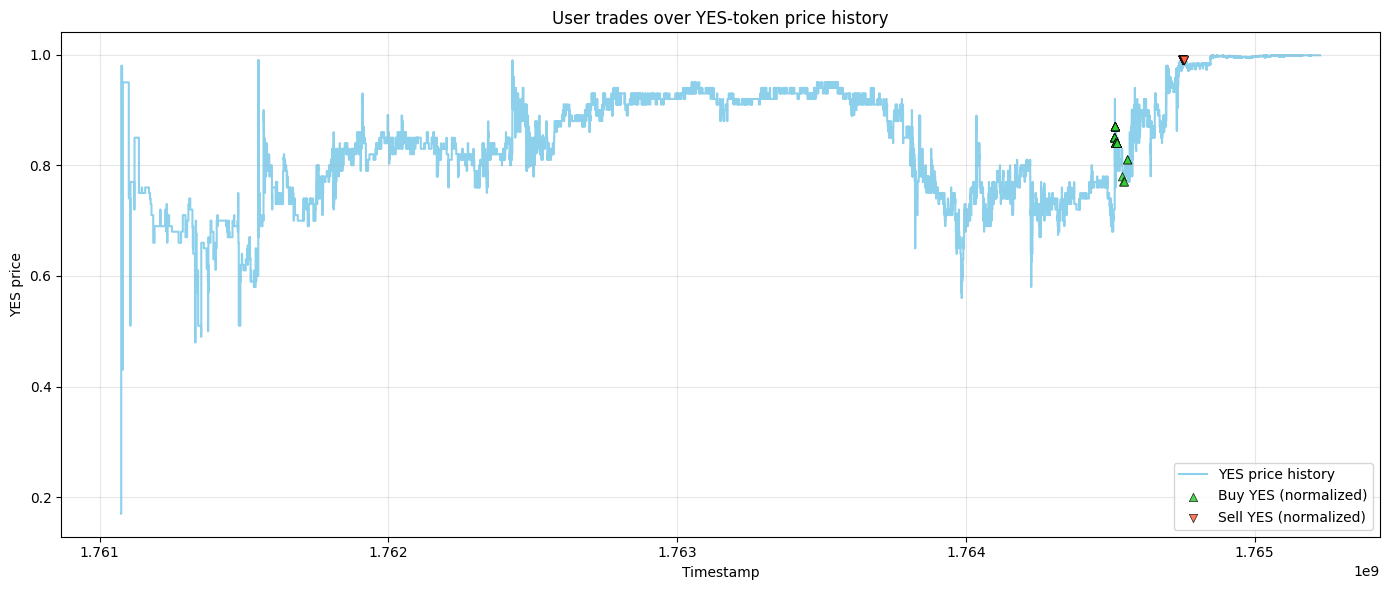


Predicted probability of being an insider: 0.2806


0.28062385742854457

In [50]:
WALLET = '0x4b7e367dd40de1d629a09bc414ec7b14e97c8736' 
SLUG = 'will-stable-launch-a-token-in-2025'

check_candidate(WALLET, SLUG)

In [ ]:
"""0xe3a1bd7fa34f49c5e11eb20787400090d9cd1ede""" 
#will-lighter-perform-an-airdrop-by-december-31 
#will-stable-launch-a-token-in-2025

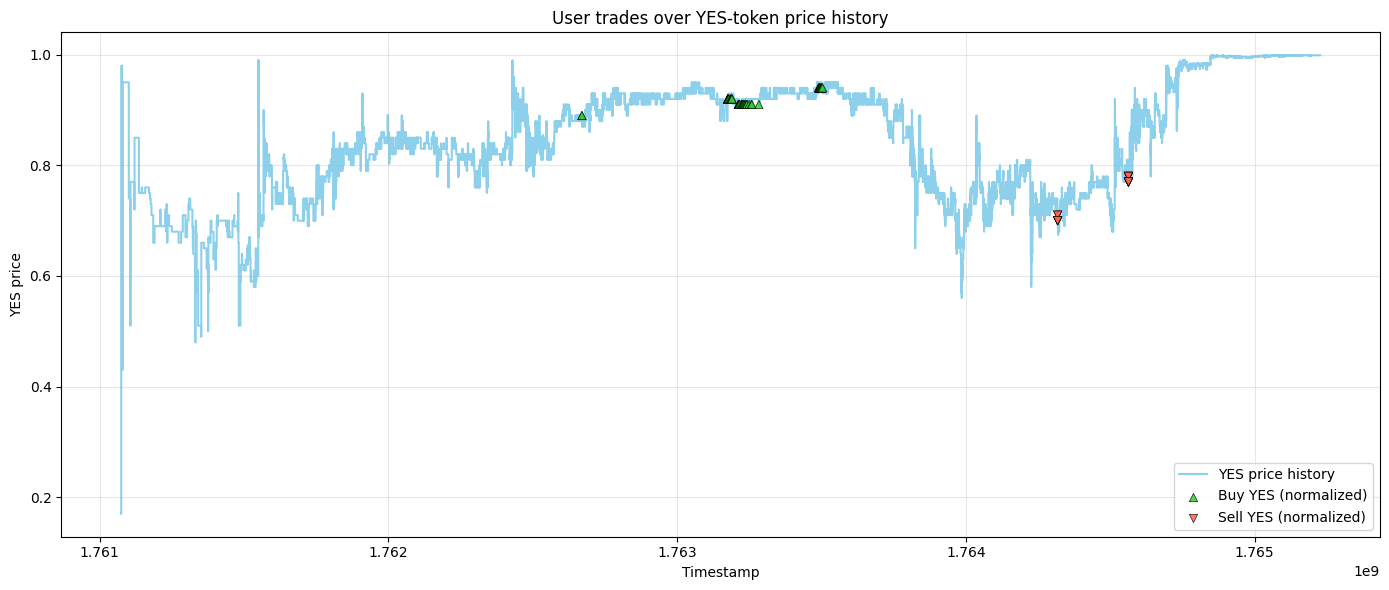


Predicted probability of being an insider: 0.2668


0.2667853630783828

In [51]:
WALLET = '0xe3a1bd7fa34f49c5e11eb20787400090d9cd1ede' 
SLUG = 'will-stable-launch-a-token-in-2025'

check_candidate(WALLET, SLUG)

Fetching market: will-lighter-perform-an-airdrop-by-december-31
[polycluster] get_orderfilled_events: 2 token(s), window=[1750968372, 1767086375] (16118003s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[INFO] timeout on [1750968372, 1767086375] for side=maker; splitting into [1750968372, 1759027373] and [1759027374, 1767086375]
[polycluster]   (1/4) token 1/2 side=maker: 22089 rows in 188.6s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1765197548, 1765323469] for side=taker; splitting into [1765197548, 1765260508] and [1765260509, 1765323469]
[polycluster]   (2/4) token 1/2 side=taker: 33979 rows in 1693.3s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[INFO] timeout on [1750968372, 1767086375] for side=maker; splitting into [1750968372, 1759027373] and [1759027374, 1767086375]
[INFO] timeout on [1766189183, 1766204922] for side=maker; splitting into [1766189183, 1766197052] and [1766197053, 1766204922]
[polycluster]   (3/4) token 2/2

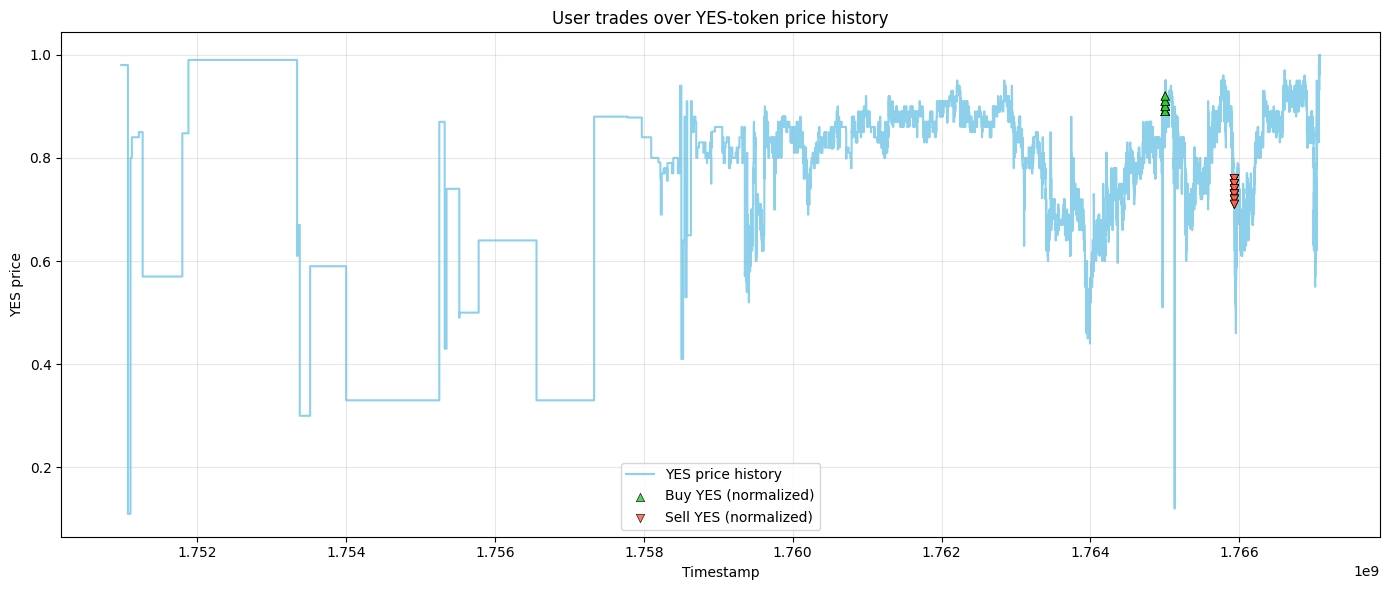


Predicted probability of being an insider: 0.2239


0.22389469166986814

In [52]:
WALLET = '0xe3a1bd7fa34f49c5e11eb20787400090d9cd1ede' 
SLUG = 'will-lighter-perform-an-airdrop-by-december-31'

check_candidate(WALLET, SLUG)

In [ ]:
"""0xc8809a2756d80cbbf5c81a685f2ce113b3242c56""" #will-stable-launch-a-token-in-2025

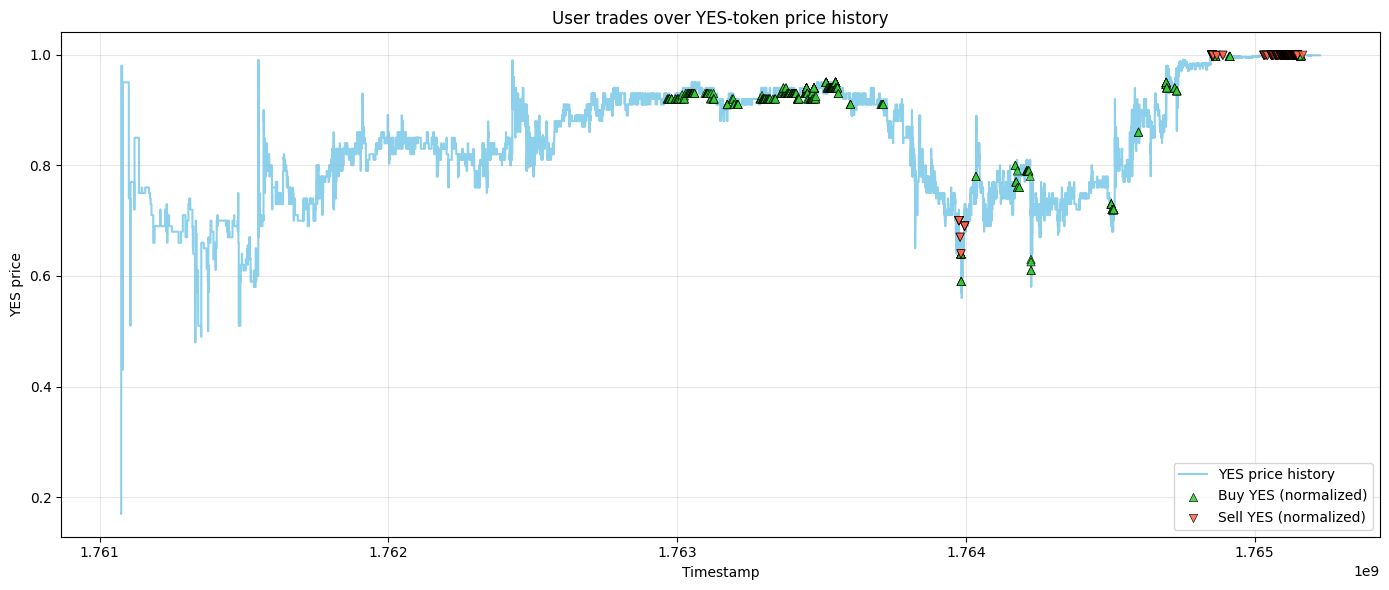


Predicted probability of being an insider: 0.2373


0.23729224934298984

In [53]:
WALLET = '0xc8809a2756d80cbbf5c81a685f2ce113b3242c56' 
SLUG = 'will-stable-launch-a-token-in-2025'

check_candidate(WALLET, SLUG)

In [ ]:
"""0xa430506774f9efaf39903ee7e0db1351f66891ca""" 
#will-yulia-navalnaya-win-the-nobel-peace-prize-in-2025 
#will-mara-corina-machado-win-the-nobel-peace-prize-in-2025


Fetching market: will-yulia-navalnaya-win-the-nobel-peace-prize-in-2025
[polycluster] get_orderfilled_events: 2 token(s), window=[1751989365, 1760098344] (8108979s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 1366 rows in 9.6s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 2561 rows in 16.7s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 857 rows in 5.9s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 2247 rows in 15.5s
[polycluster] get_orderfilled_events: done, 7031 unique rows in 47.8s
  cached: events=7031, wallets=1384


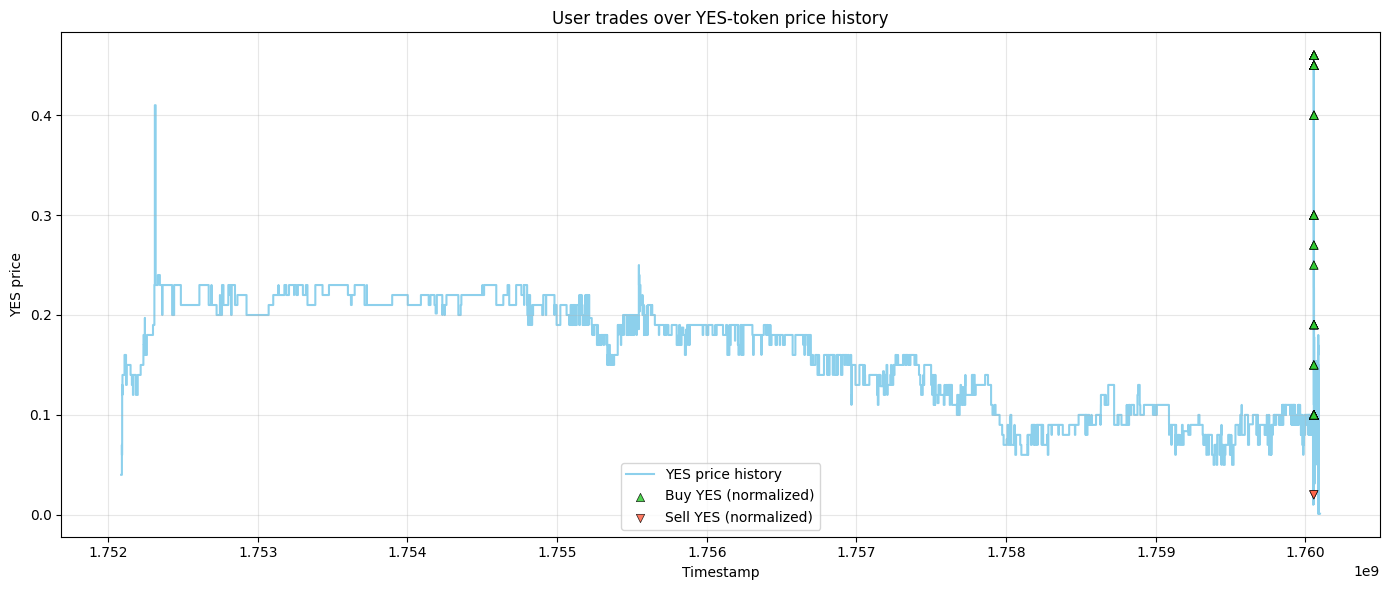


Predicted probability of being an insider: 0.0252


0.02518220027266167

In [54]:
WALLET = '0xa430506774f9efaf39903ee7e0db1351f66891ca' 
SLUG = 'will-yulia-navalnaya-win-the-nobel-peace-prize-in-2025'

check_candidate(WALLET, SLUG)

Fetching market: will-mara-corina-machado-win-the-nobel-peace-prize-in-2025
[polycluster] get_orderfilled_events: 2 token(s), window=[1751989363, 1760098282] (8108919s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 2732 rows in 23.1s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 4054 rows in 29.7s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 3484 rows in 26.3s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 5334 rows in 40.8s
[polycluster] get_orderfilled_events: done, 15604 unique rows in 120.0s
  cached: events=15604, wallets=3598


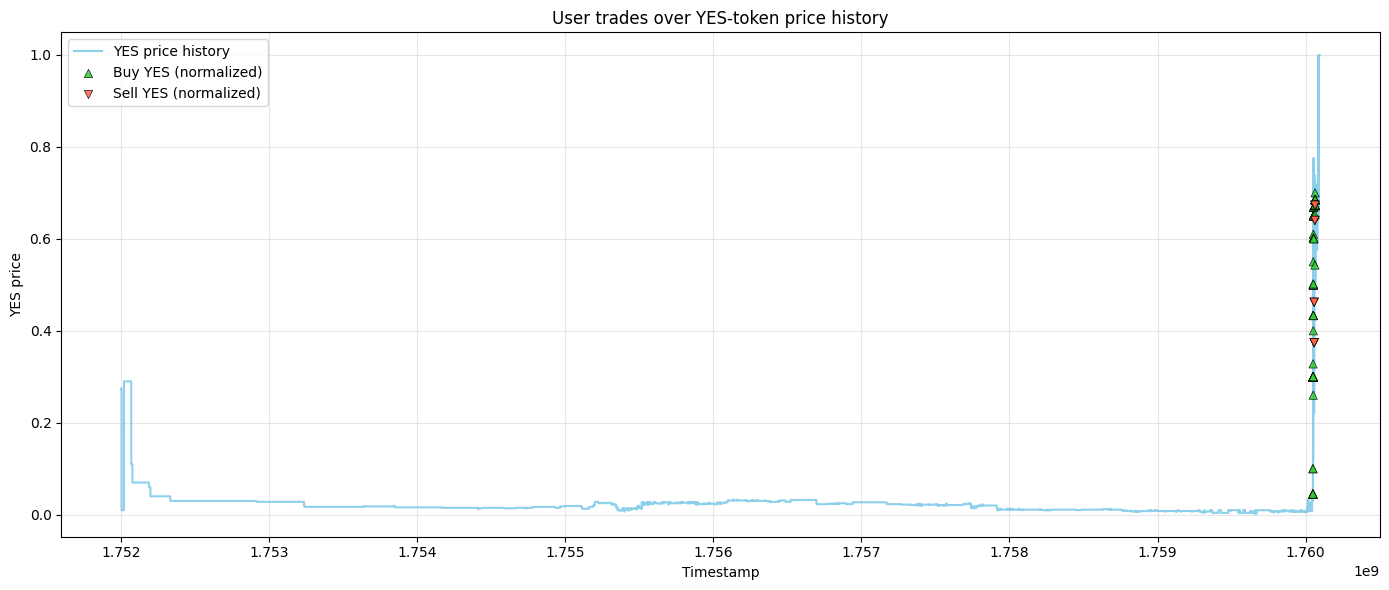


Predicted probability of being an insider: 0.3054


0.30537087074999447

In [55]:
WALLET = '0xa430506774f9efaf39903ee7e0db1351f66891ca' 
SLUG = 'will-mara-corina-machado-win-the-nobel-peace-prize-in-2025'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x234cc49e43dff8b3207bbd3a8a2579f339cb9867"""       "this guy made 1 prediction in hislife and won" 
#will-mara-corina-machado-win-the-nobel-peace-prize-in-2025 

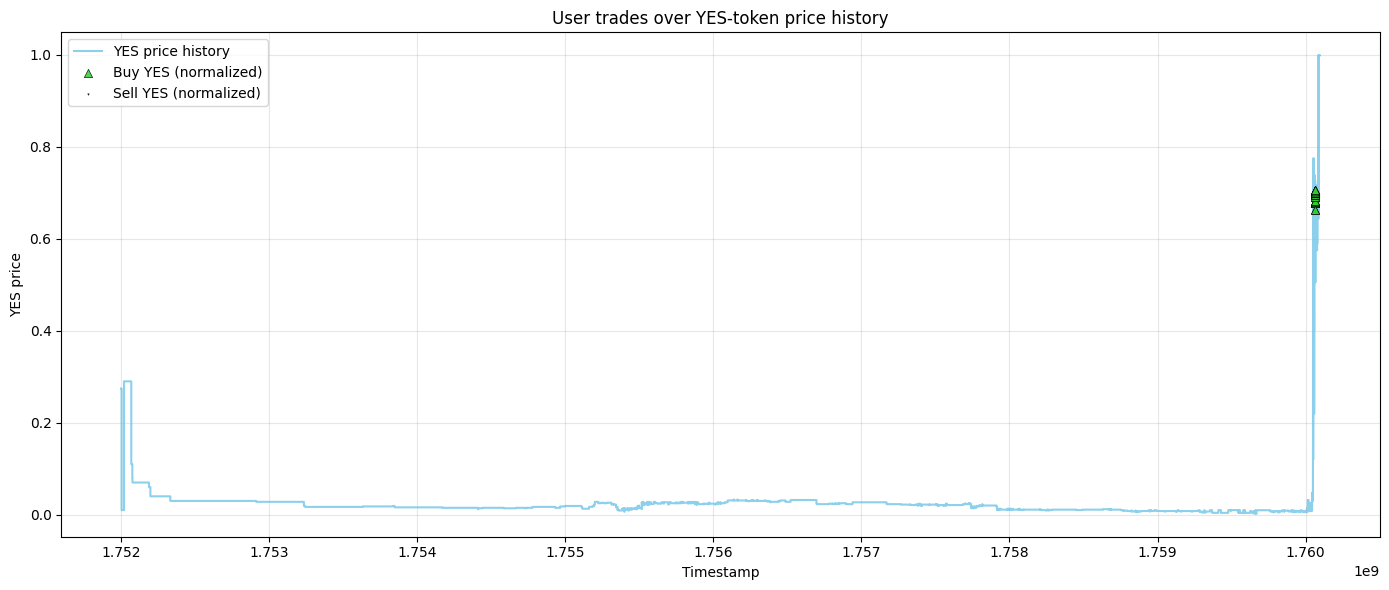


Predicted probability of being an insider: 0.5828


0.5828068092301563

In [56]:
WALLET = '0x234cc49e43dff8b3207bbd3a8a2579f339cb9867' 
SLUG = 'will-mara-corina-machado-win-the-nobel-peace-prize-in-2025'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x1d9af60c679cd0b577c3c4ccb4b1a4be4174426d""" #will-axiom-be-accused-of-insider-trading 


In [59]:
import importlib
import polycluster.events
importlib.reload(polycluster.events)
from polycluster.events import get_market_orderfilled_events


Fetching market: will-axiom-be-accused-of-insider-trading
[polycluster] get_orderfilled_events: 2 token(s), window=[1771866080, 1772122278] (256198s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 8677 rows in 53.6s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1772038215, 1772039215] for side=taker; splitting into [1772038215, 1772038715] and [1772038716, 1772039215]
[INFO] timeout on [1772039216, 1772040216] for side=taker; splitting into [1772039216, 1772039716] and [1772039717, 1772040216]
[INFO] timeout on [1772114273, 1772115273] for side=taker; splitting into [1772114273, 1772114773] and [1772114774, 1772115273]
[INFO] timeout on [1772115274, 1772116274] for side=taker; splitting into [1772115274, 1772115774] and [1772115775, 1772116274]
[INFO] timeout on [1772115775, 1772116274] for side=taker; splitting into [1772115775, 1772116024] and [1772116025, 1772116274]
[polycluster]   (2/4) token 1/2 sid

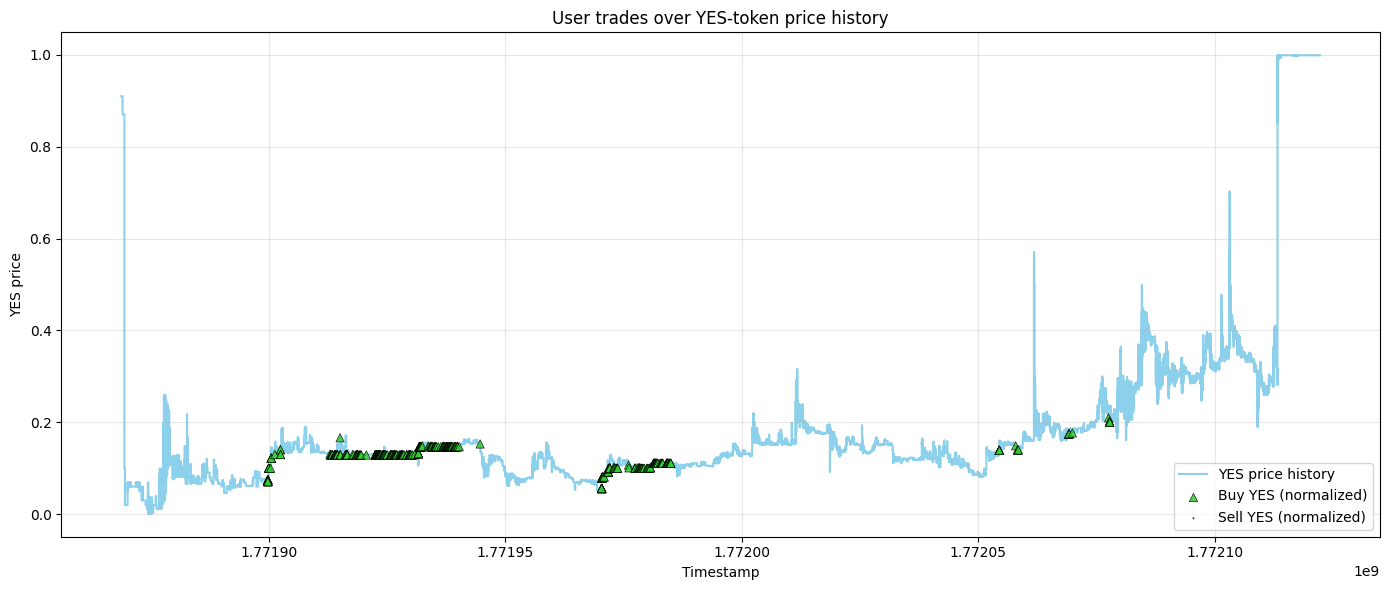


Predicted probability of being an insider: 0.9591


0.9591046745138136

In [60]:
WALLET = '0x1d9af60c679cd0b577c3c4ccb4b1a4be4174426d' 
SLUG = 'will-axiom-be-accused-of-insider-trading'

check_candidate(WALLET, SLUG)

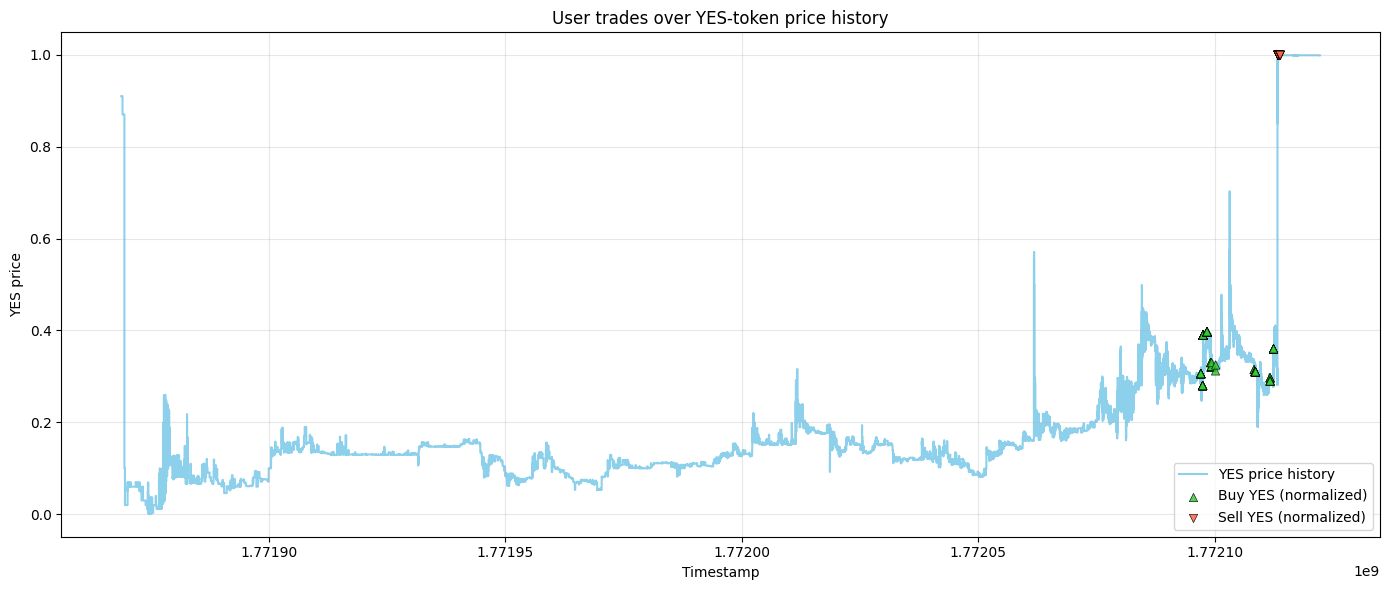


Predicted probability of being an insider: 0.2241


0.2240589588582574

In [61]:
WALLET = '0xe56526b27b96f009b31ddb46558a134047bfce48' 
SLUG = 'will-axiom-be-accused-of-insider-trading'

check_candidate(WALLET, SLUG)

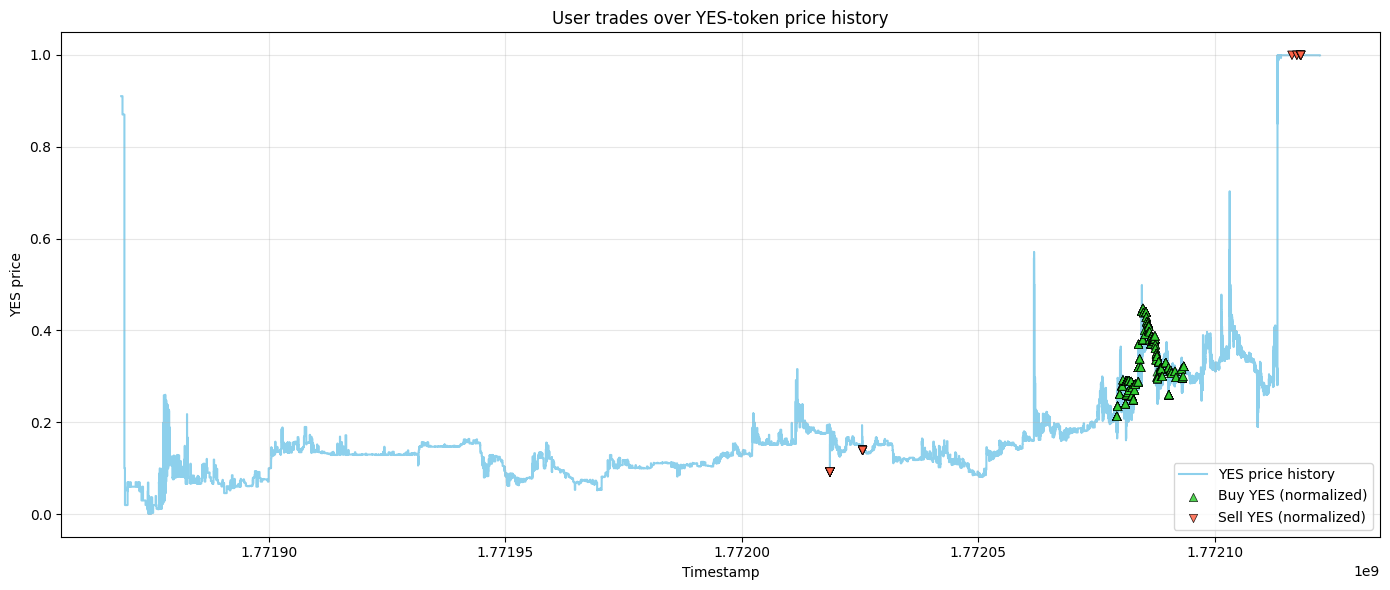


Predicted probability of being an insider: 0.3017


0.30169501204595156

In [62]:
WALLET = '0x054ec2f0ccfdae941886a3ed306635068c716639' 
SLUG = 'will-axiom-be-accused-of-insider-trading'

check_candidate(WALLET, SLUG)

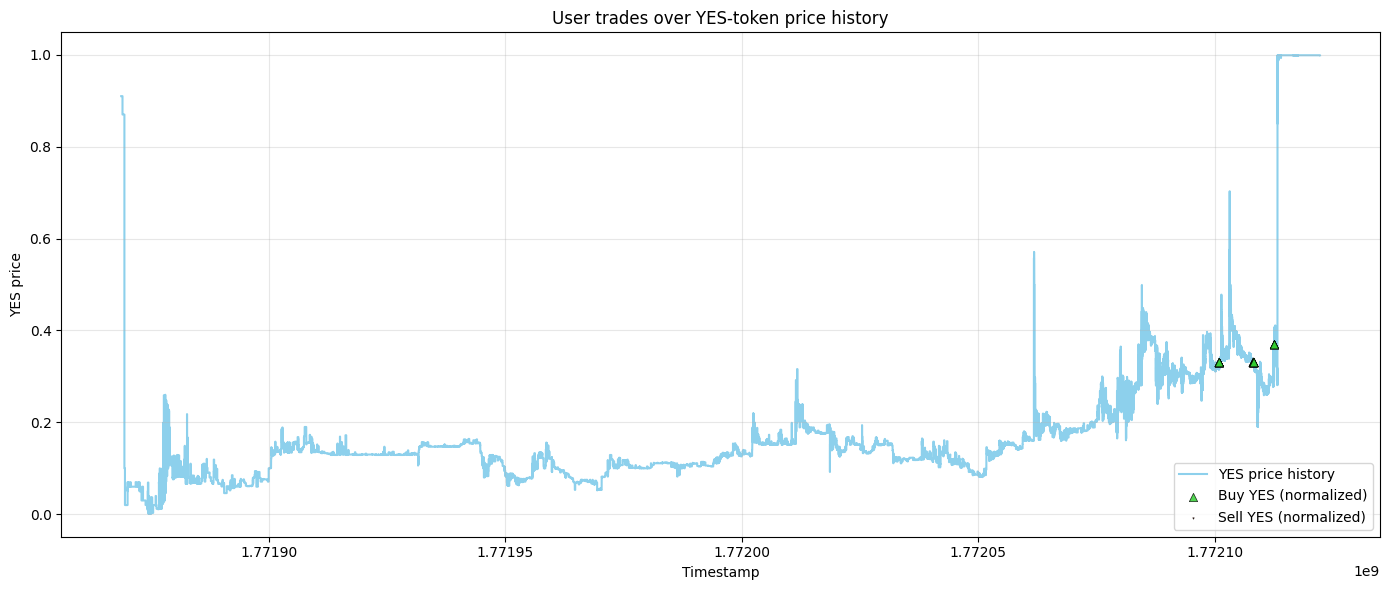


Predicted probability of being an insider: 0.8962


0.8962418991360427

In [63]:
WALLET = '0x6d6affce1ed04a0e9611484daf1cef5cbcf3fb40' 
SLUG = 'will-axiom-be-accused-of-insider-trading'

check_candidate(WALLET, SLUG)

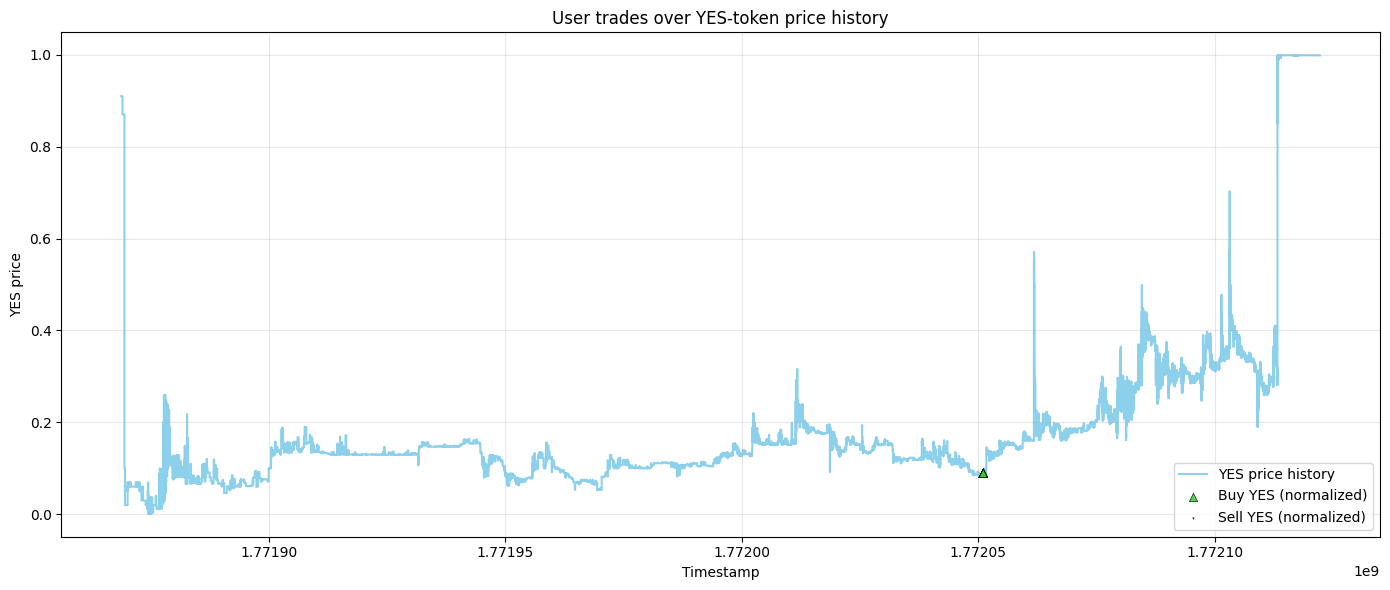


Predicted probability of being an insider: 0.9653


0.9653091817982329

In [64]:
WALLET = '0x581f34349babaf03b2d3c8f5f60cf44ffbe19a3a' 
SLUG = 'will-axiom-be-accused-of-insider-trading'

check_candidate(WALLET, SLUG)

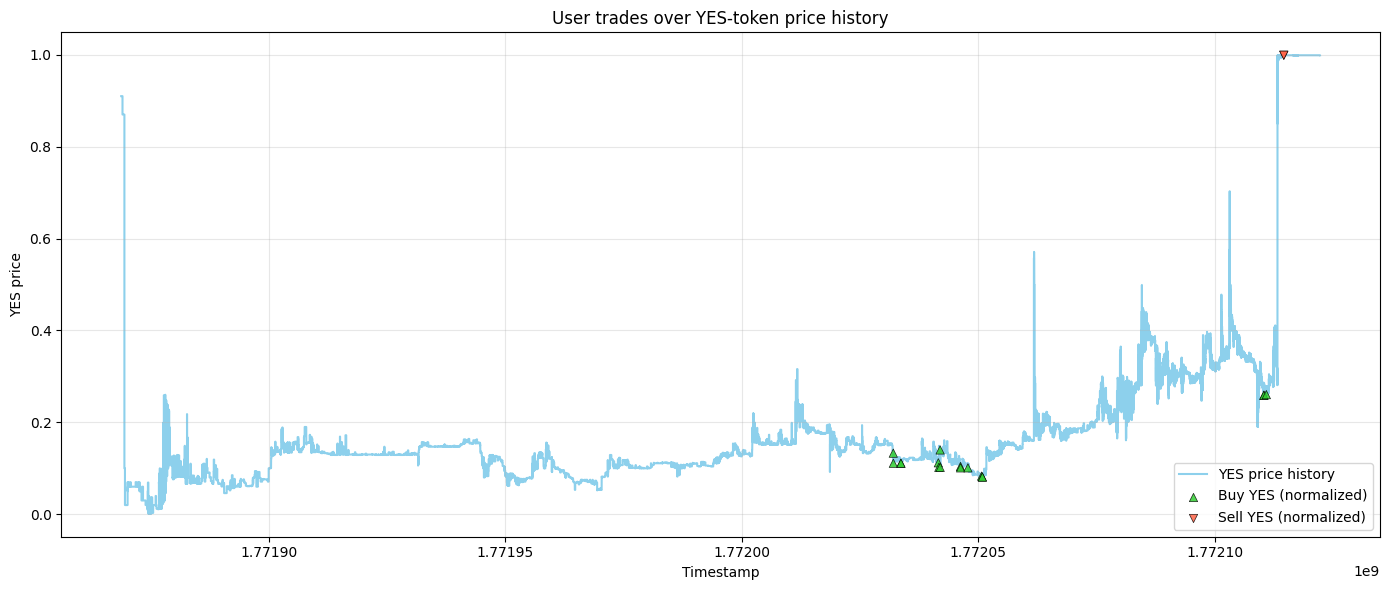


Predicted probability of being an insider: 0.2240


0.22402827764158992

In [65]:
WALLET = '0xaab29084bcc42daff9e11b4a5a4cc55cda3eb306' 
SLUG = 'will-axiom-be-accused-of-insider-trading'

check_candidate(WALLET, SLUG)

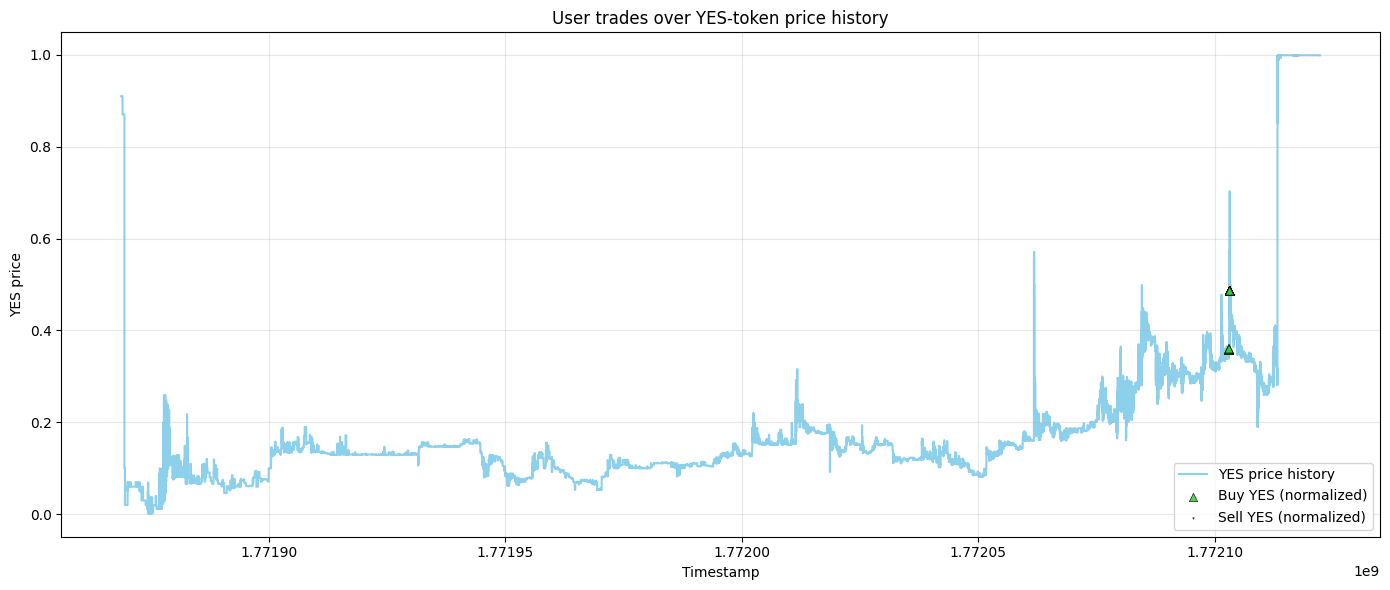


Predicted probability of being an insider: 0.8365


0.8365477413905732

In [66]:
WALLET = '0x98a96619e482700e83e8486e4f3727dba17f5381' 
SLUG = 'will-axiom-be-accused-of-insider-trading'

check_candidate(WALLET, SLUG)

In [ ]:
"""0x95bd107886bd48d6737029603e3db242fb781652""" 
#us-strikes-iran-by-february-28-2026-227-967-547-688-589-491-592-418-452-924-384-915-464-672-196-157-993-596-269-535-381-391-471-256-988-997-296-225-762-973-292-827-345-182-558-215-794-879-189-761 
#us-strikes-iran-by-march-1-2026-492 
#will-us-or-israel-strike-iran-by-february-28-2026-766


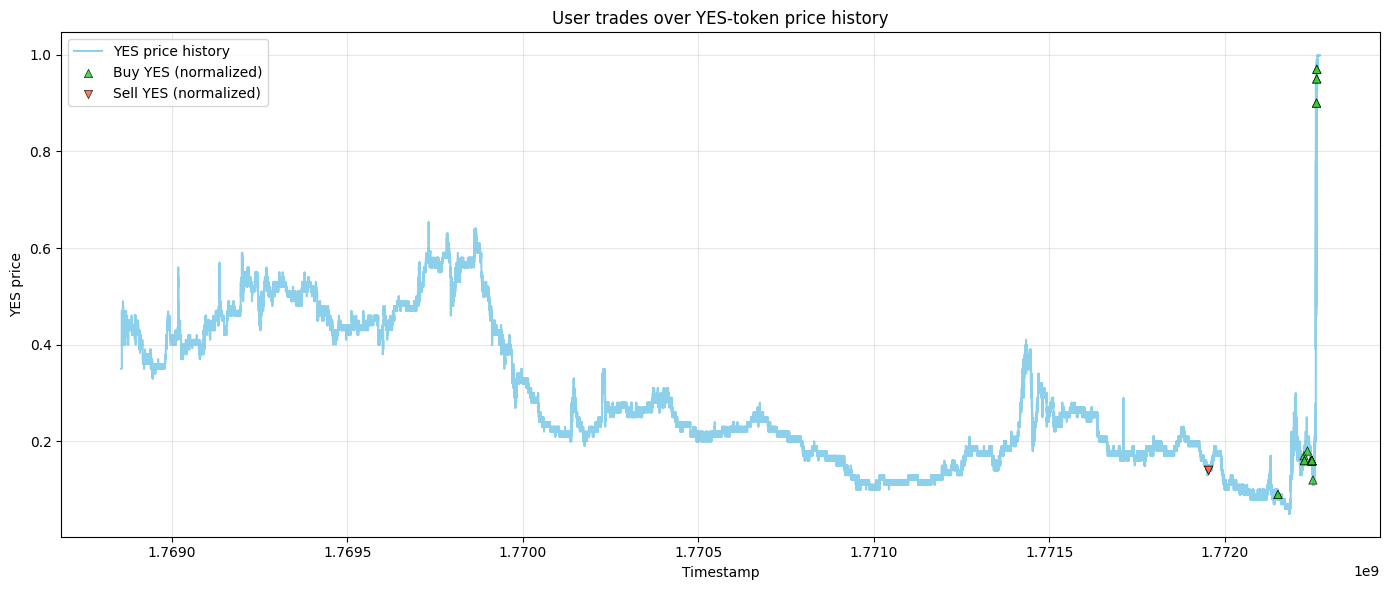


Predicted probability of being an insider: 0.8994


0.89938062480053

In [67]:
WALLET = '0x95bd107886bd48d6737029603e3db242fb781652' 
SLUG = 'us-strikes-iran-by-february-28-2026-227-967-547-688-589-491-592-418-452-924-384-915-464-672-196-157-993-596-269-535-381-391-471-256-988-997-296-225-762-973-292-827-345-182-558-215-794-879-189-761'

check_candidate(WALLET, SLUG)

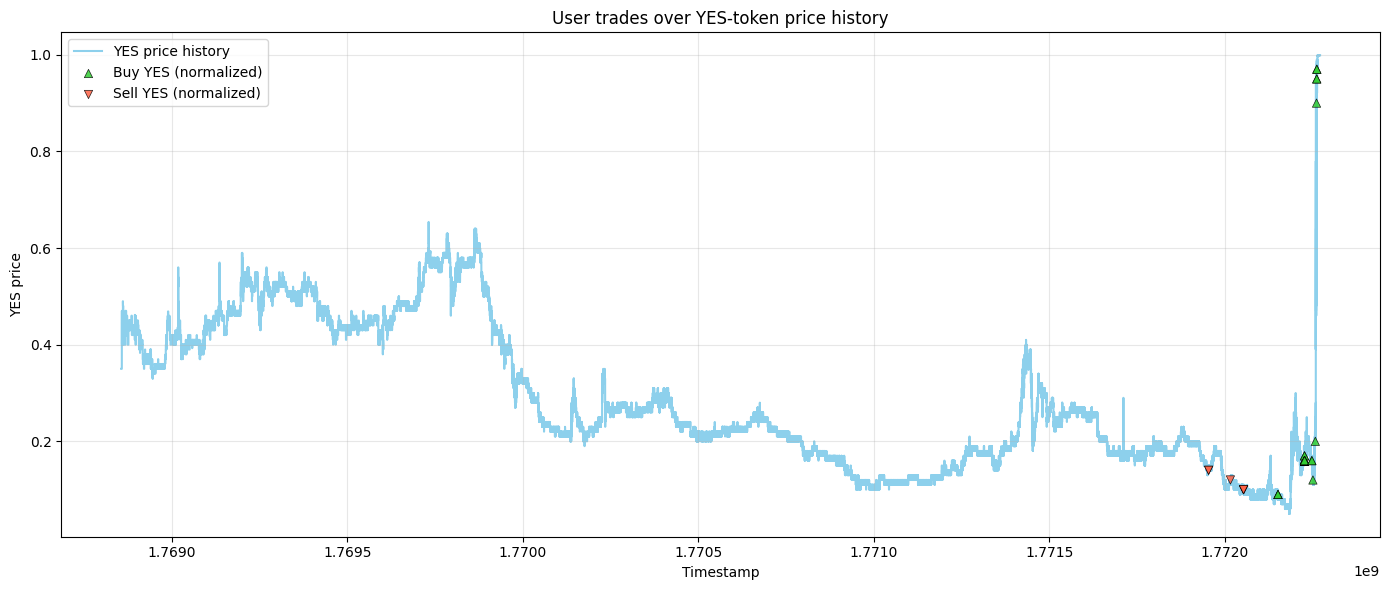


Predicted probability of being an insider: 0.8162


0.8162326681616936

In [68]:
WALLET = '0x943117ea8e3f5b160e158c1c4b1786fee5d3e5a0' 
SLUG = 'us-strikes-iran-by-february-28-2026-227-967-547-688-589-491-592-418-452-924-384-915-464-672-196-157-993-596-269-535-381-391-471-256-988-997-296-225-762-973-292-827-345-182-558-215-794-879-189-761'

check_candidate(WALLET, SLUG)

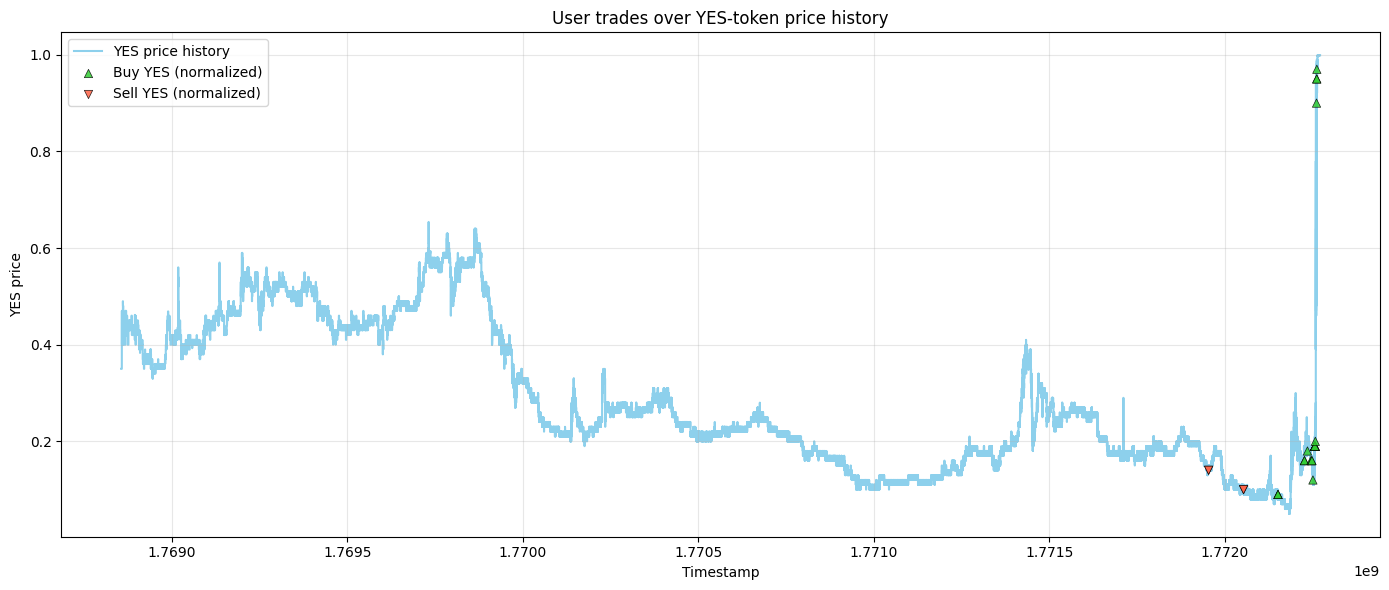


Predicted probability of being an insider: 0.8825


0.8825133984994114

In [69]:
WALLET = '0x4ec2f11d2893eb1bc3bab7449910540c93adf7ec' 
SLUG = 'us-strikes-iran-by-february-28-2026-227-967-547-688-589-491-592-418-452-924-384-915-464-672-196-157-993-596-269-535-381-391-471-256-988-997-296-225-762-973-292-827-345-182-558-215-794-879-189-761'

check_candidate(WALLET, SLUG)

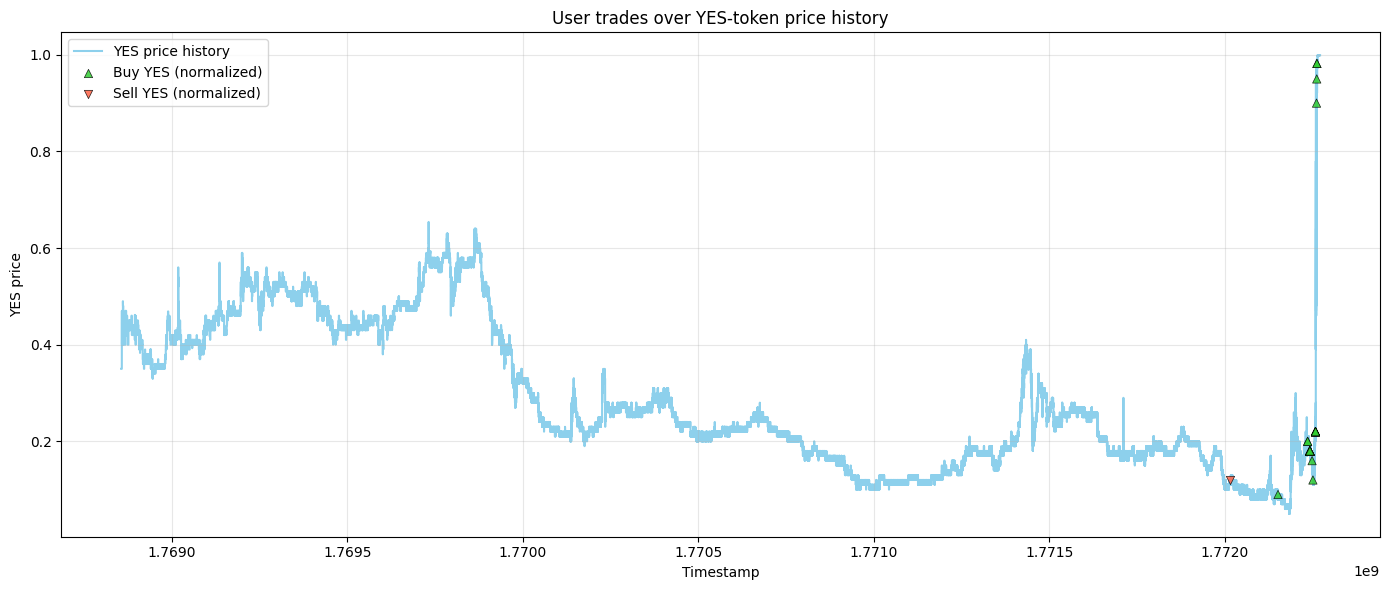


Predicted probability of being an insider: 0.9089


0.9089297042178643

In [70]:
WALLET = '0x421b26a47bb5136d045190d7870095eb29498469' 
SLUG = 'us-strikes-iran-by-february-28-2026-227-967-547-688-589-491-592-418-452-924-384-915-464-672-196-157-993-596-269-535-381-391-471-256-988-997-296-225-762-973-292-827-345-182-558-215-794-879-189-761'

check_candidate(WALLET, SLUG)

In [ ]:
#us-strikes-iran-by-march-1-2026-492 

Fetching market: us-strikes-iran-by-march-1-2026-492
[polycluster] get_orderfilled_events: 2 token(s), window=[1771527900, 1772271107] (743207s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 6344 rows in 46.1s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 11953 rows in 86.9s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 5803 rows in 40.7s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 12621 rows in 90.7s
[polycluster] get_orderfilled_events: done, 36721 unique rows in 264.7s
  cached: events=36721, wallets=5641


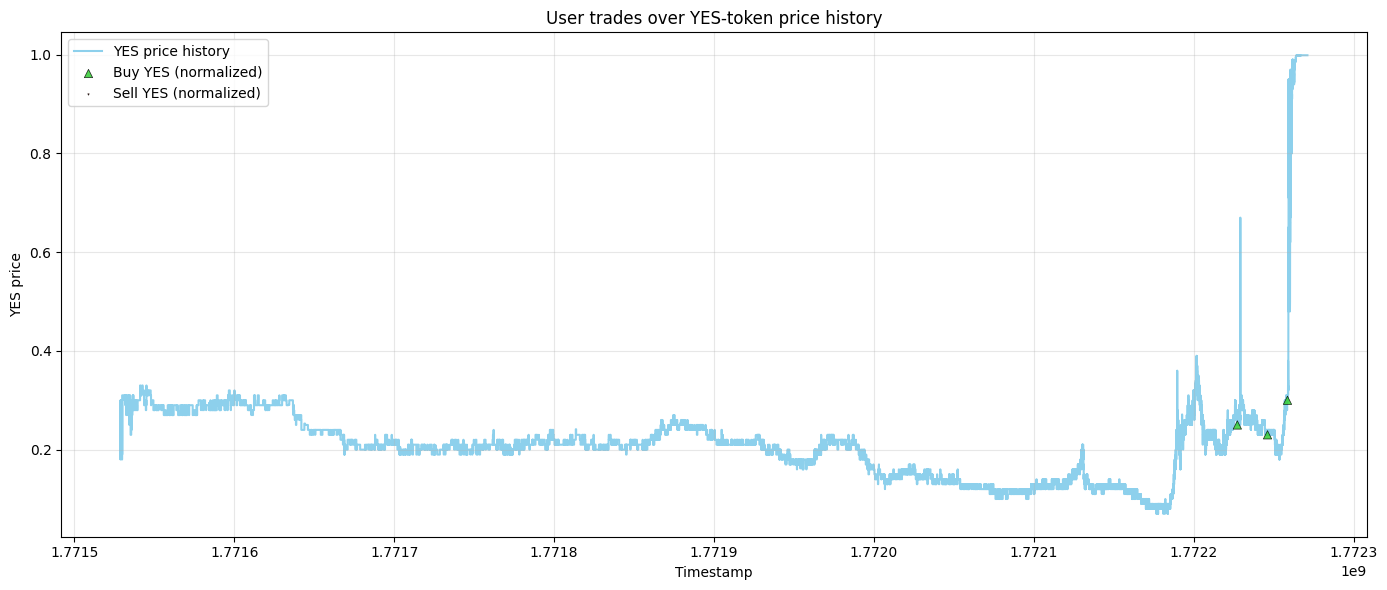


Predicted probability of being an insider: 0.9474


0.9474286744435848

In [71]:
WALLET = '0x95bd107886bd48d6737029603e3db242fb781652' 
SLUG = 'us-strikes-iran-by-march-1-2026-492'
check_candidate(WALLET, SLUG)

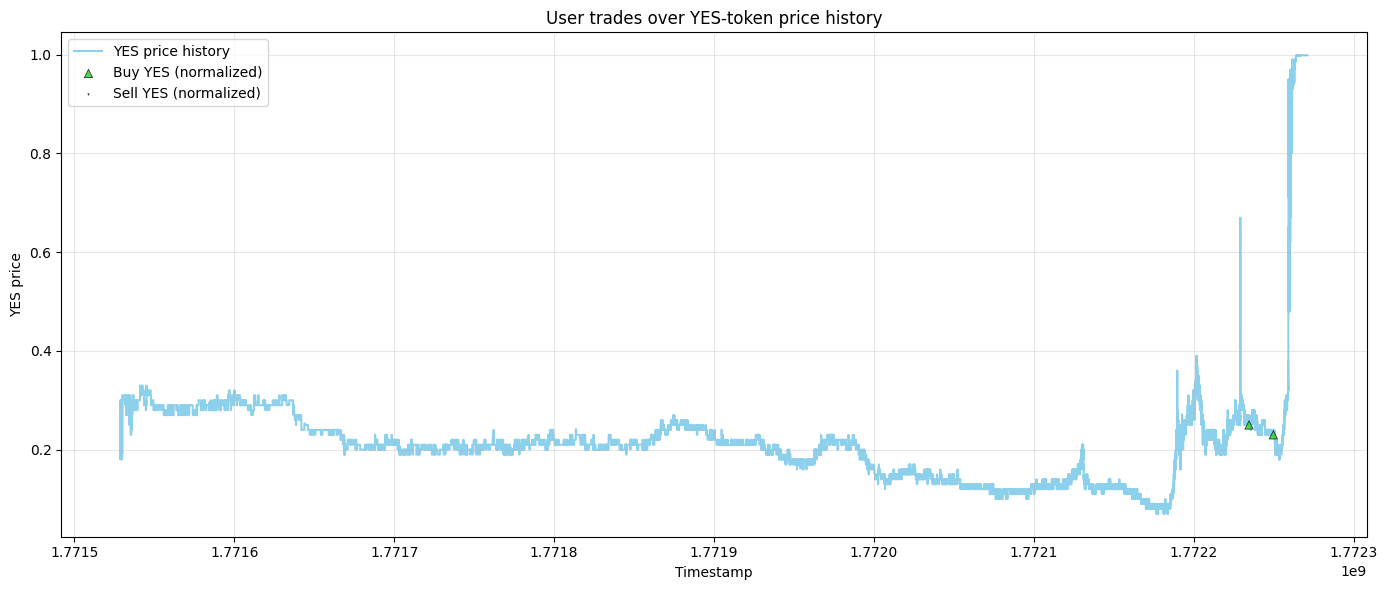


Predicted probability of being an insider: 0.9460


0.9460221329204596

In [72]:
WALLET = '0xfffee3116390fc9415956617ed048d26c7c1b424' 
SLUG = 'us-strikes-iran-by-march-1-2026-492'
check_candidate(WALLET, SLUG)

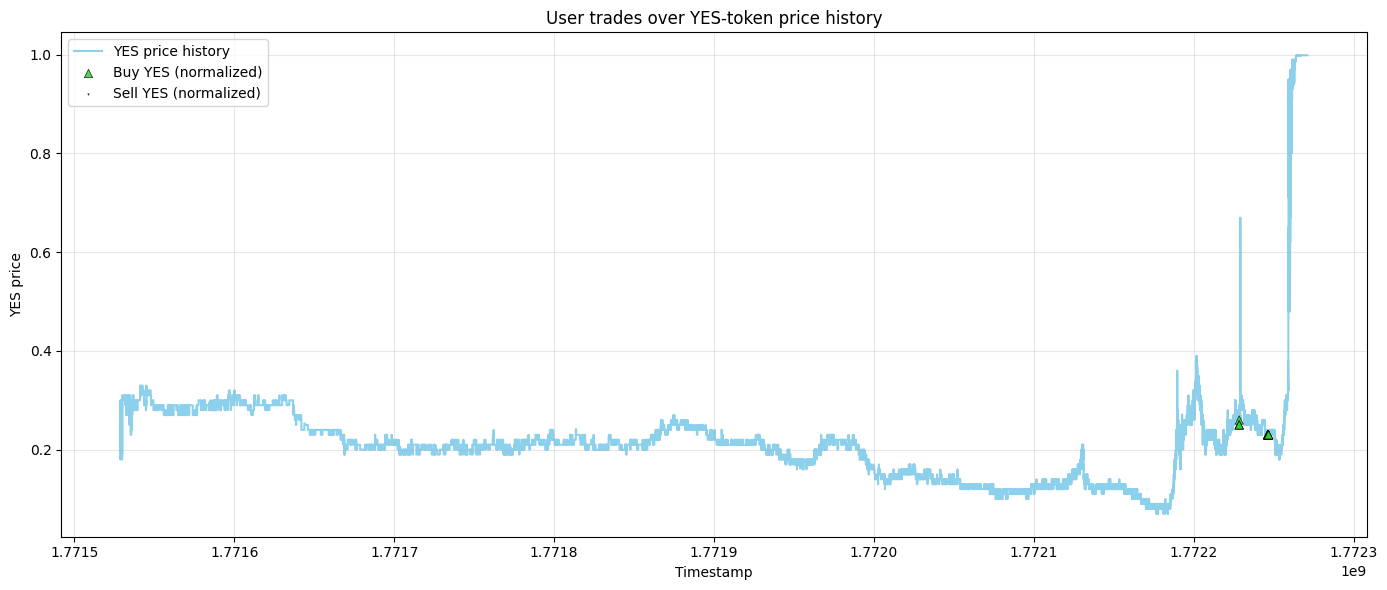


Predicted probability of being an insider: 0.9465


0.9464979116825792

In [73]:
WALLET = '0xeee545e9706a03e73c5d17632e2bbb6f1096cce1' 
SLUG = 'us-strikes-iran-by-march-1-2026-492'
check_candidate(WALLET, SLUG)

In [ ]:
#khamenei-out-as-supreme-leader-of-iran-by-march-31

Fetching market: khamenei-out-as-supreme-leader-of-iran-by-march-31
[polycluster] get_orderfilled_events: 2 token(s), window=[1765500054, 1772585881] (7085827s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[INFO] timeout on [1765500054, 1772585881] for side=maker; splitting into [1765500054, 1769042967] and [1769042968, 1772585881]
[polycluster]   (1/4) token 1/2 side=maker: 33786 rows in 234.6s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[INFO] timeout on [1768416731, 1768418460] for side=taker; splitting into [1768416731, 1768417595] and [1768417596, 1768418460]
[INFO] timeout on [1772288333, 1772289197] for side=taker; splitting into [1772288333, 1772288765] and [1772288766, 1772289197]
[INFO] timeout on [1772289198, 1772290062] for side=taker; splitting into [1772289198, 1772289630] and [1772289631, 1772290062]
[INFO] timeout on [1772306498, 1772307362] for side=taker; splitting into [1772306498, 1772306930] and [1772306931, 1772307362]
[INFO] timeout on [177

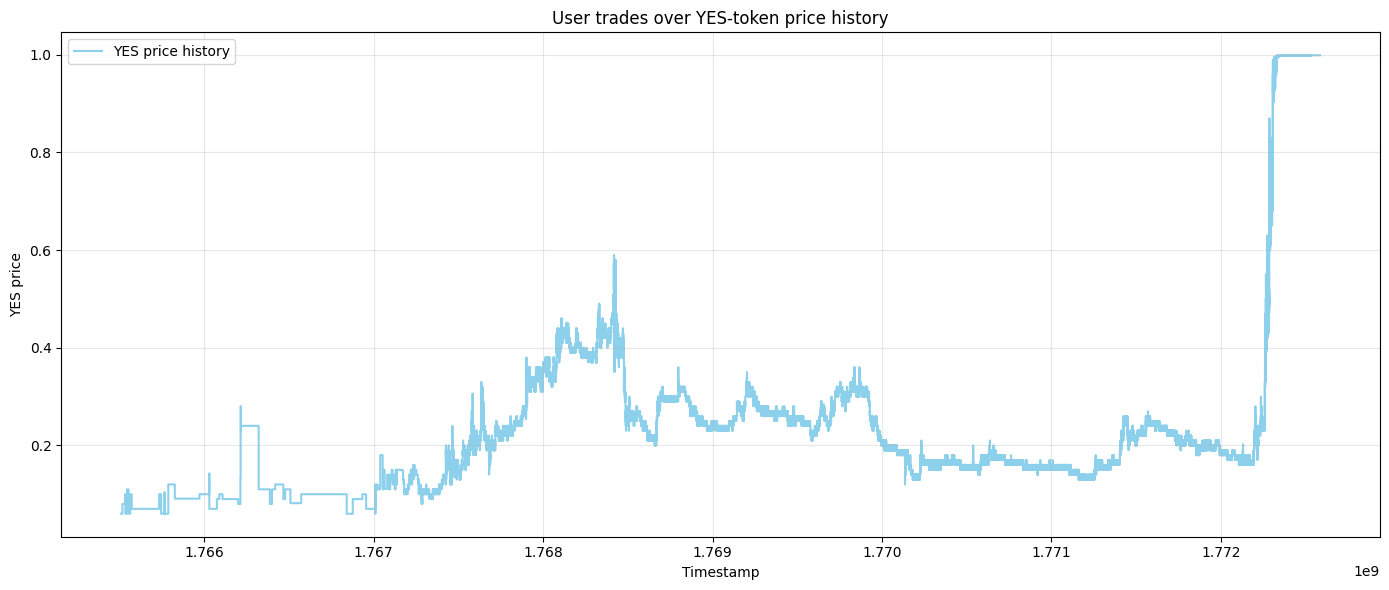


Predicted probability of being an insider: 0.2241


0.22407602936675303

In [74]:
WALLET = '0xb390ae2cc3fd8cb2670a62129faeb775faee106c' 
SLUG = 'khamenei-out-as-supreme-leader-of-iran-by-march-31'
check_candidate(WALLET, SLUG)

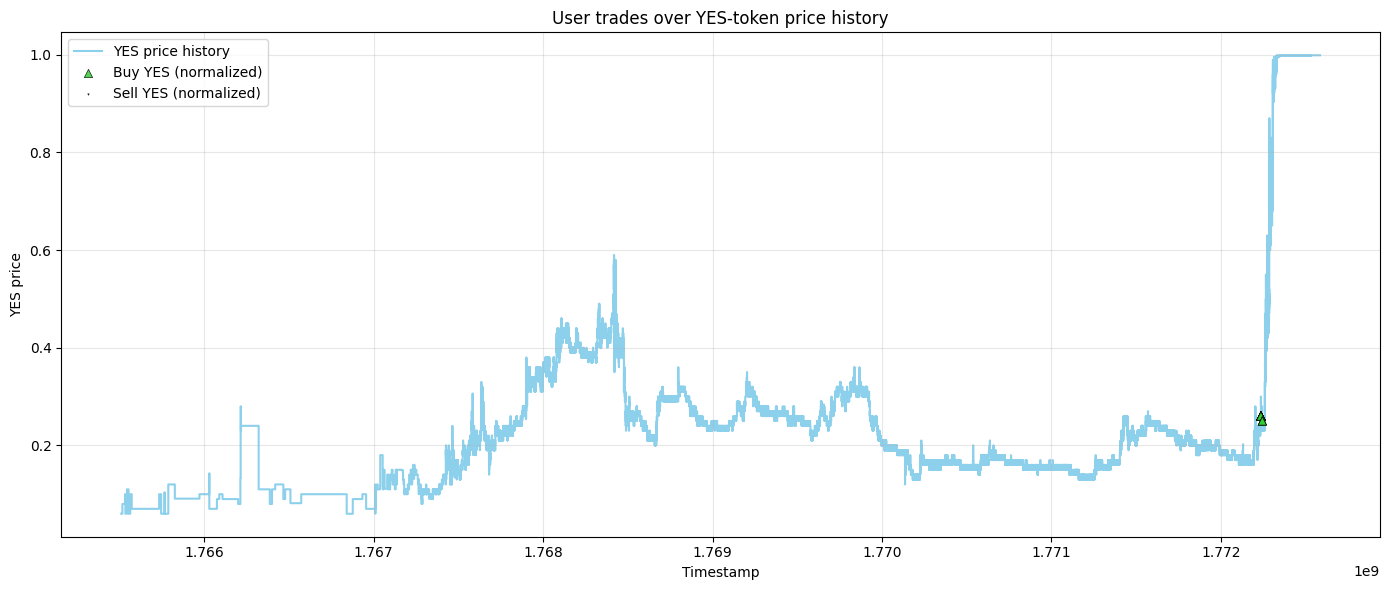


Predicted probability of being an insider: 0.9382


0.9382031745176066

In [75]:
WALLET = '0x3e545810f8b95dd0fcf4114b0246a0dbb40ad1c5' 
SLUG = 'khamenei-out-as-supreme-leader-of-iran-by-march-31'
check_candidate(WALLET, SLUG)

In [ ]:
"""0xe4b2396323001f880d1429400f5a8259845e5dc9""" 
#will-openai-release-a-new-frontier-model-on-december-11 
#will-openai-release-a-new-frontier-model-by-december-13-683


Fetching market: will-openai-release-a-new-frontier-model-on-december-11
[polycluster] get_orderfilled_events: 2 token(s), window=[1765235063, 1765858513] (623450s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 1449 rows in 9.9s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 4554 rows in 29.5s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 1790 rows in 16.1s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 4849 rows in 33.5s
[polycluster] get_orderfilled_events: done, 12642 unique rows in 89.1s
  cached: events=12642, wallets=1970


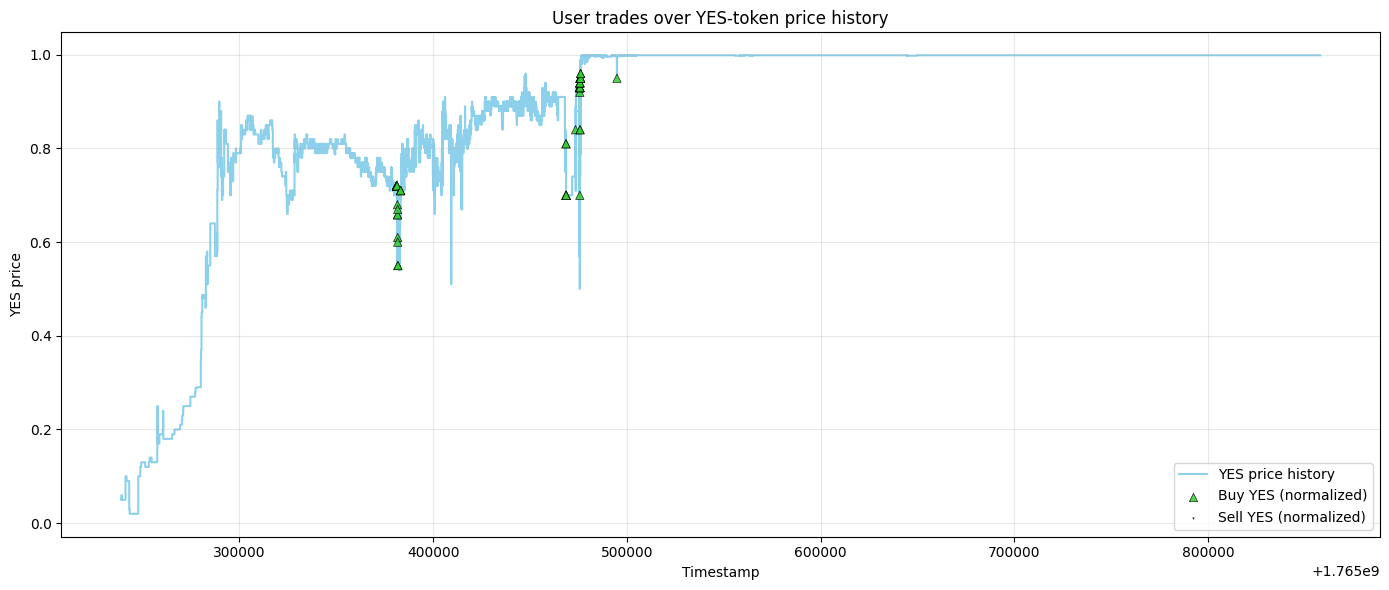


Predicted probability of being an insider: 0.4400


0.44002743353982243

In [76]:
WALLET = '0xe4b2396323001f880d1429400f5a8259845e5dc9' 
SLUG = 'will-openai-release-a-new-frontier-model-on-december-11'
check_candidate(WALLET, SLUG)

Fetching market: will-openai-release-a-new-frontier-model-by-december-13-683
[polycluster] get_orderfilled_events: 2 token(s), window=[1764907269, 1765489427] (582158s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 1694 rows in 11.6s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 3479 rows in 22.3s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 2329 rows in 18.6s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 3726 rows in 27.0s
[polycluster] get_orderfilled_events: done, 11228 unique rows in 79.6s
  cached: events=11228, wallets=1716


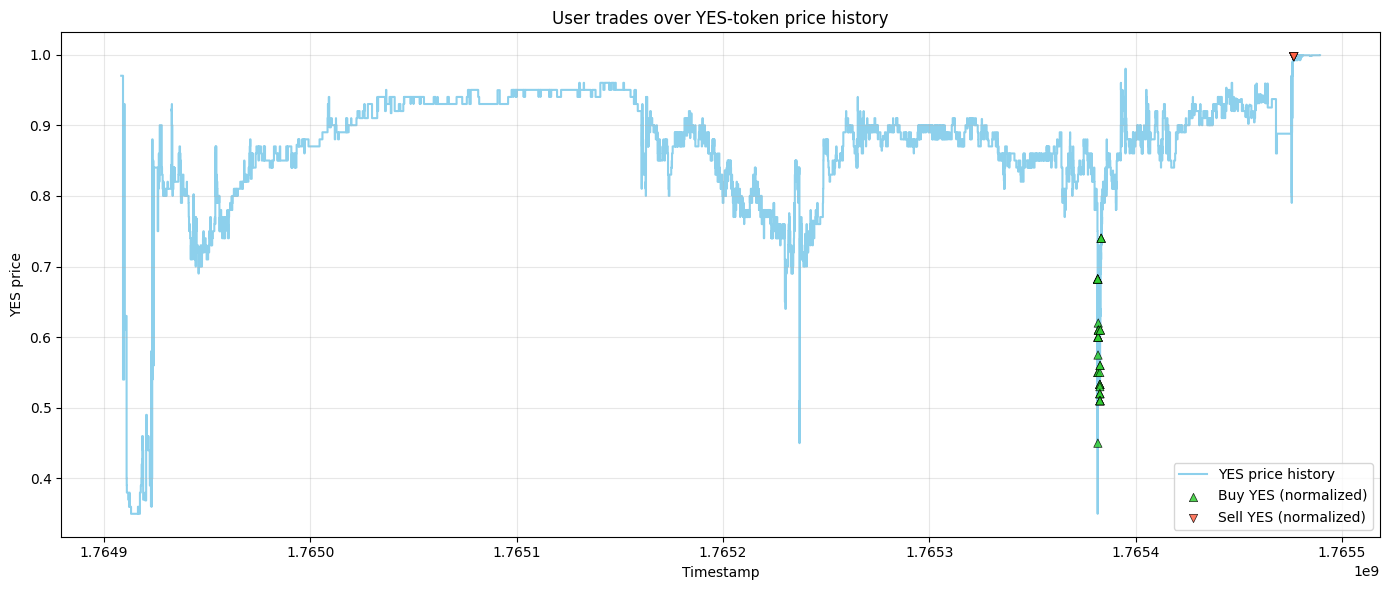


Predicted probability of being an insider: 0.6291


0.629095095110187

In [77]:
WALLET = '0xe4b2396323001f880d1429400f5a8259845e5dc9' 
SLUG = 'will-openai-release-a-new-frontier-model-by-december-13-683'
check_candidate(WALLET, SLUG)

In [ ]:
"""0x7868856f93438c59a0b052161098a27768a65fc0""" 
#openai-browser-by-october-31 
#openai-social-app-in-2025 
#openai-browser-in-2025


Fetching market: openai-browser-by-october-31
[polycluster] get_orderfilled_events: 2 token(s), window=[1756329999, 1761075293] (4745294s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 4417 rows in 29.0s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 10256 rows in 64.5s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 4771 rows in 32.0s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 10529 rows in 72.9s
[polycluster] get_orderfilled_events: done, 29973 unique rows in 198.5s
  cached: events=29973, wallets=3600


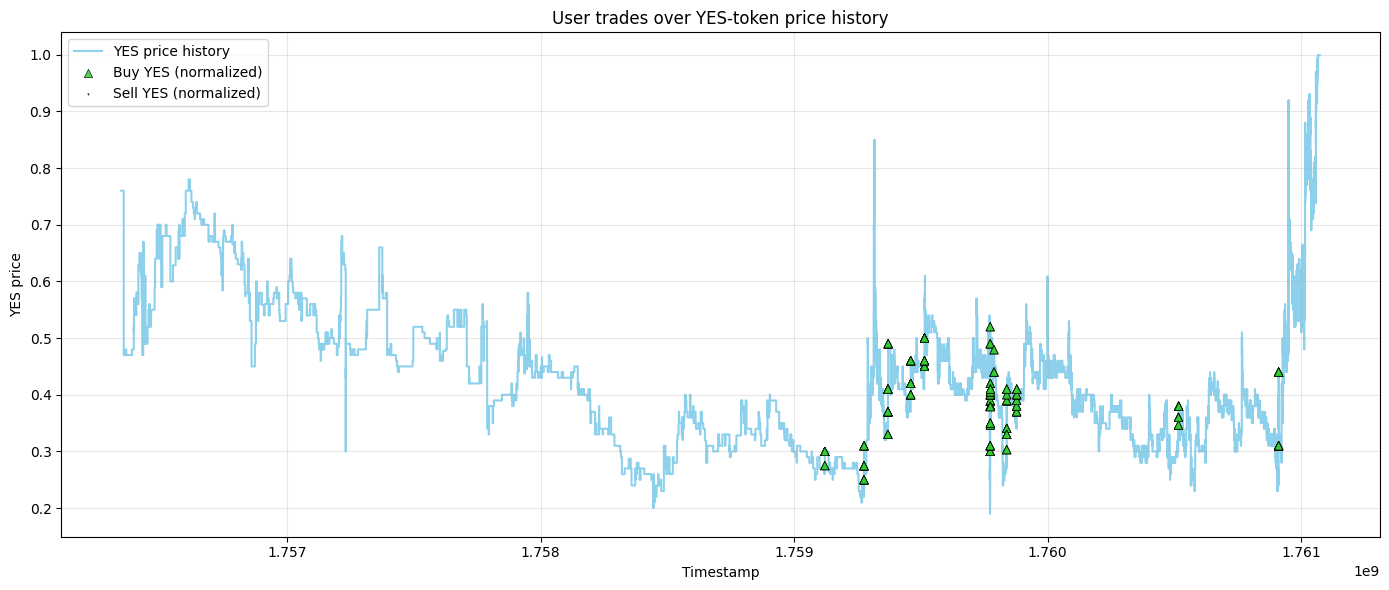


Predicted probability of being an insider: 0.9330


0.9329609323109938

In [78]:
WALLET = '0x7868856f93438c59a0b052161098a27768a65fc0' 
SLUG = 'openai-browser-by-october-31'
check_candidate(WALLET, SLUG)

Fetching market: openai-social-app-in-2025
[polycluster] get_orderfilled_events: 2 token(s), window=[1744760699, 1759262415] (14501716s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 1116 rows in 7.6s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 2157 rows in 14.9s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 1490 rows in 9.4s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 2923 rows in 17.7s
[polycluster] get_orderfilled_events: done, 7686 unique rows in 49.5s
  cached: events=7686, wallets=965


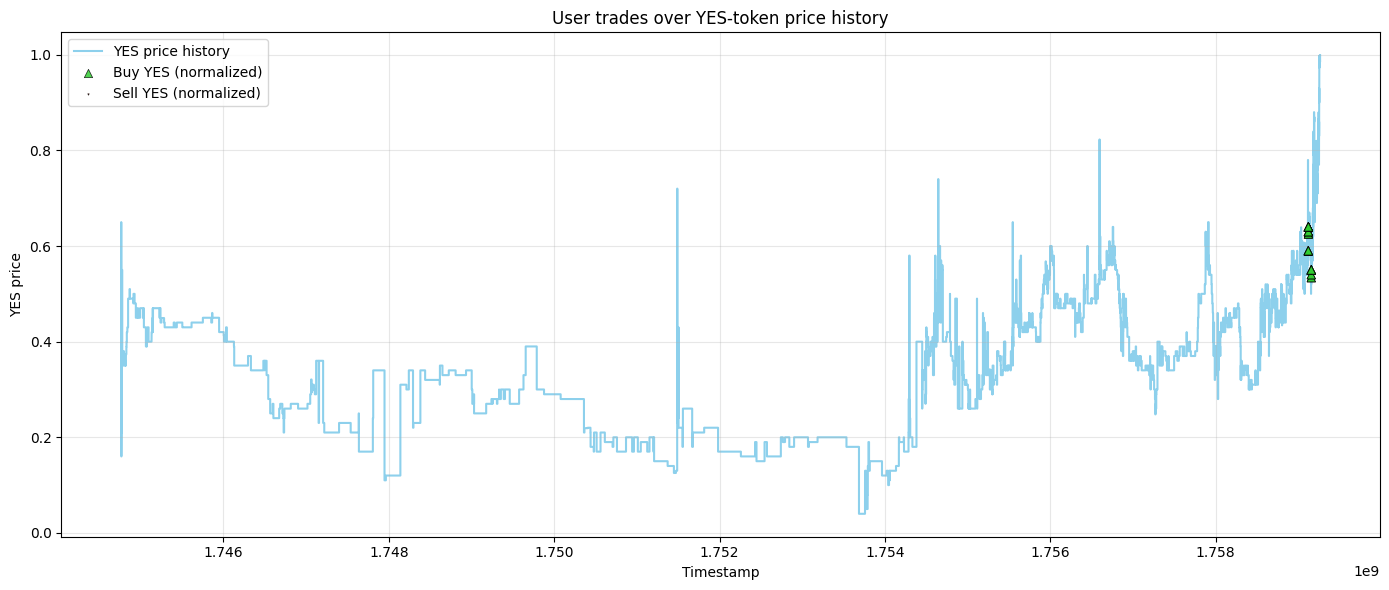


Predicted probability of being an insider: 0.7031


0.7031243217499201

In [79]:
WALLET = '0x7868856f93438c59a0b052161098a27768a65fc0' 
SLUG = 'openai-social-app-in-2025'
check_candidate(WALLET, SLUG)

In [ ]:
"""0x40d9ac81a425f14d2c490c41ac8969c0cbcfd472""" 
#will-karol-g-perform-during-the-super-bowl-lx-halftime-show 
#will-cardi-b-perform-during-the-super-bowl-lx-halftime-show


Fetching market: will-karol-g-perform-during-the-super-bowl-lx-halftime-show
[polycluster] get_orderfilled_events: 2 token(s), window=[1770239841, 1770611875] (372034s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 385 rows in 4.2s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 897 rows in 6.2s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 361 rows in 4.3s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 821 rows in 6.9s
[polycluster] get_orderfilled_events: done, 2464 unique rows in 21.7s
  cached: events=2464, wallets=419


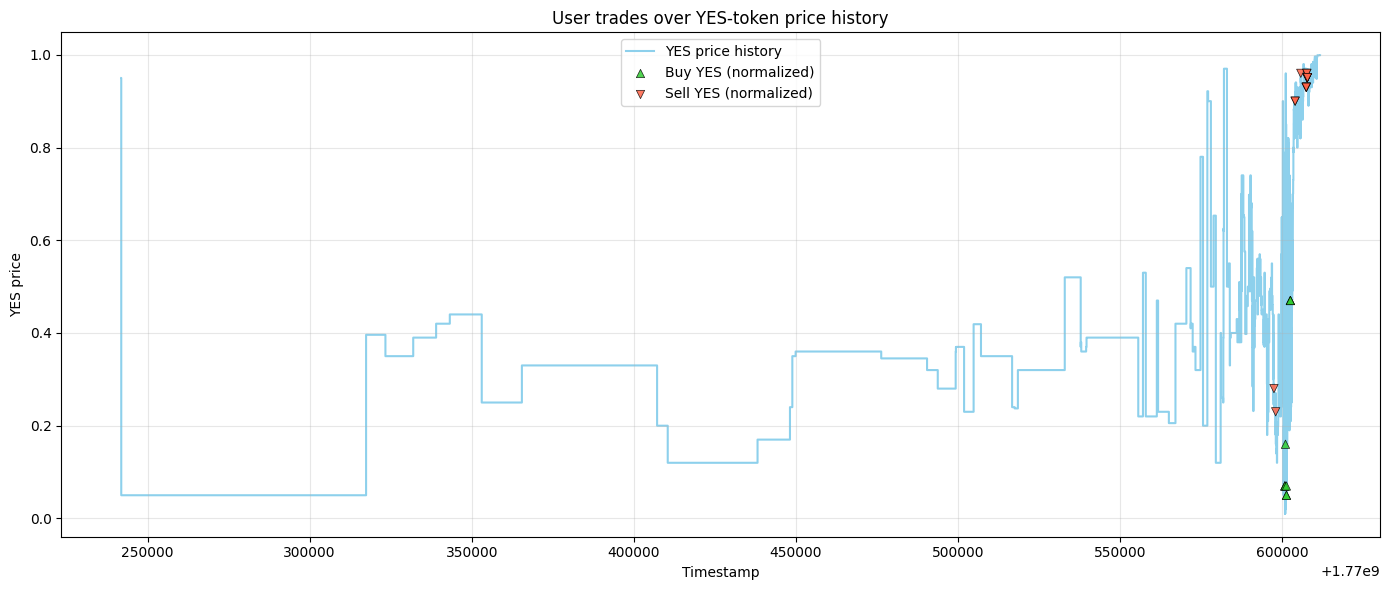


Predicted probability of being an insider: 0.2151


0.2151397690491235

In [80]:
WALLET = '0x40d9ac81a425f14d2c490c41ac8969c0cbcfd472' 
SLUG = 'will-karol-g-perform-during-the-super-bowl-lx-halftime-show'
check_candidate(WALLET, SLUG)

Fetching market: will-cardi-b-perform-during-the-super-bowl-lx-halftime-show
[polycluster] get_orderfilled_events: 2 token(s), window=[1750890706, 1770879019] (19988313s)
[polycluster]   (1/4) token 1/2 side=maker: starting...
[polycluster]   (1/4) token 1/2 side=maker: 6168 rows in 42.4s
[polycluster]   (2/4) token 1/2 side=taker: starting...
[polycluster]   (2/4) token 1/2 side=taker: 12820 rows in 93.5s
[polycluster]   (3/4) token 2/2 side=maker: starting...
[polycluster]   (3/4) token 2/2 side=maker: 3618 rows in 27.9s
[polycluster]   (4/4) token 2/2 side=taker: starting...
[polycluster]   (4/4) token 2/2 side=taker: 9950 rows in 79.4s
[polycluster] get_orderfilled_events: done, 32556 unique rows in 243.3s
  cached: events=32556, wallets=2897


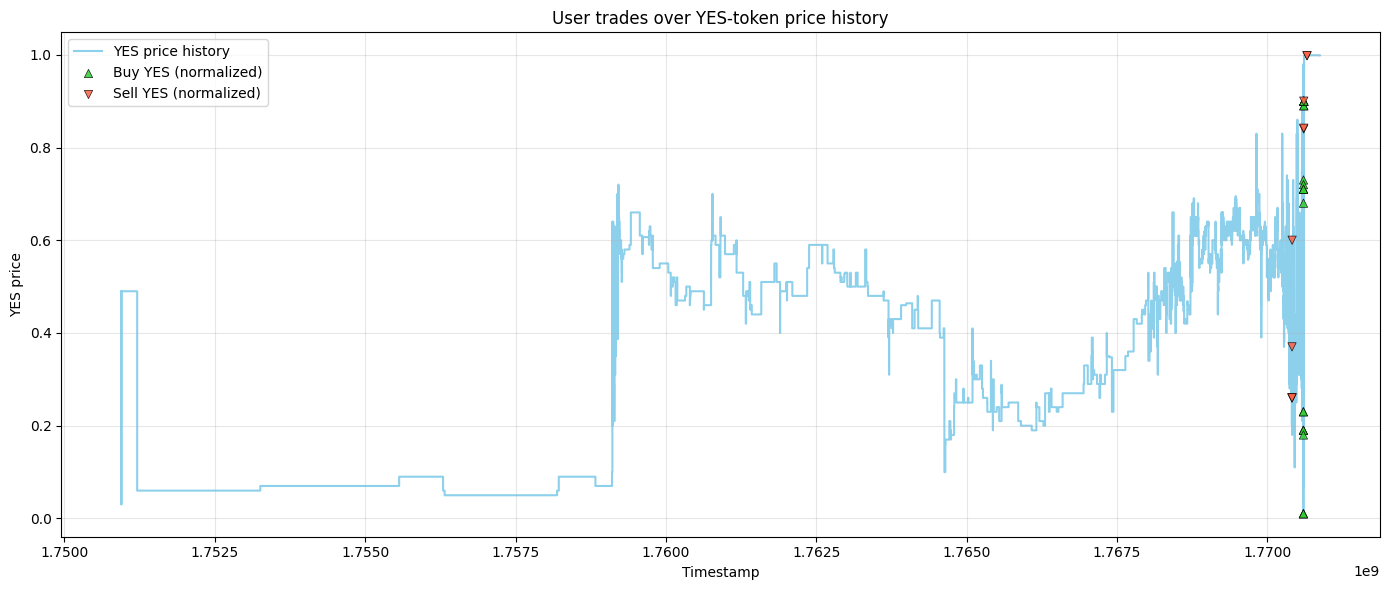


Predicted probability of being an insider: 0.2467


0.24673091692541446

In [81]:
WALLET = '0x40d9ac81a425f14d2c490c41ac8969c0cbcfd472' 
SLUG = 'will-cardi-b-perform-during-the-super-bowl-lx-halftime-show'
check_candidate(WALLET, SLUG)

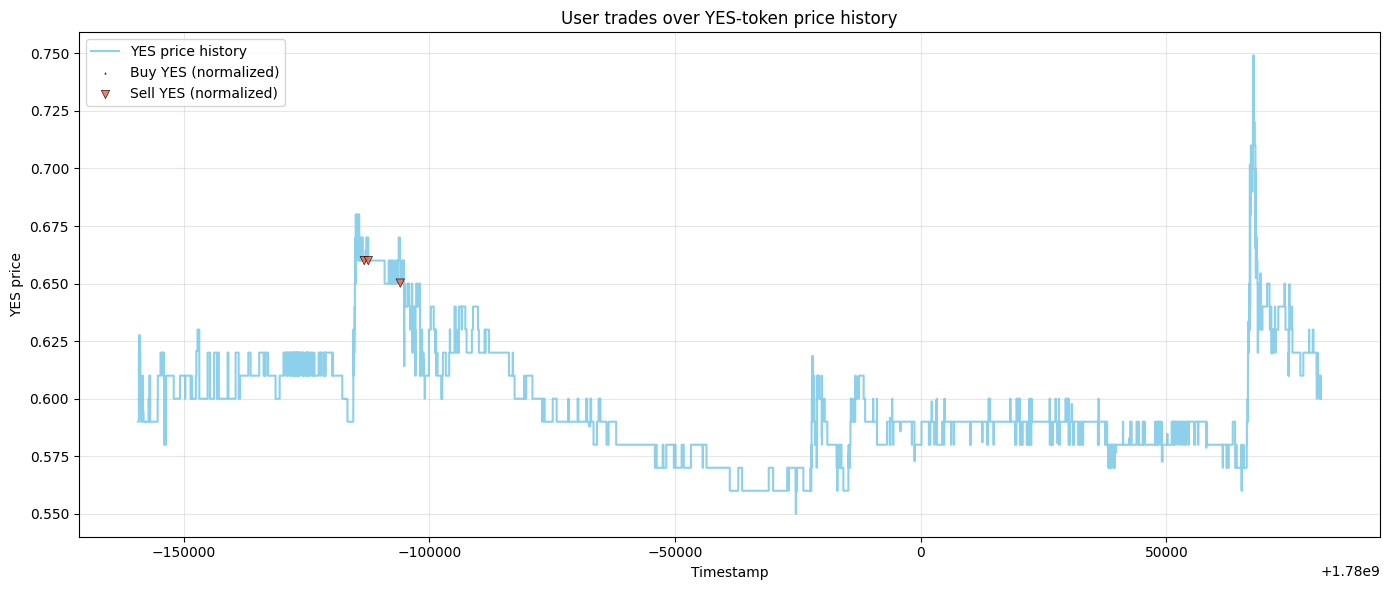

In [18]:
WALLET = '0xe94bf89e66b852d60866667bddf7bff9dad65abe'
SLUG = 'strait-of-hormuz-traffic-returns-to-normal-by-july-31'

check_candidate(WALLET, SLUG)

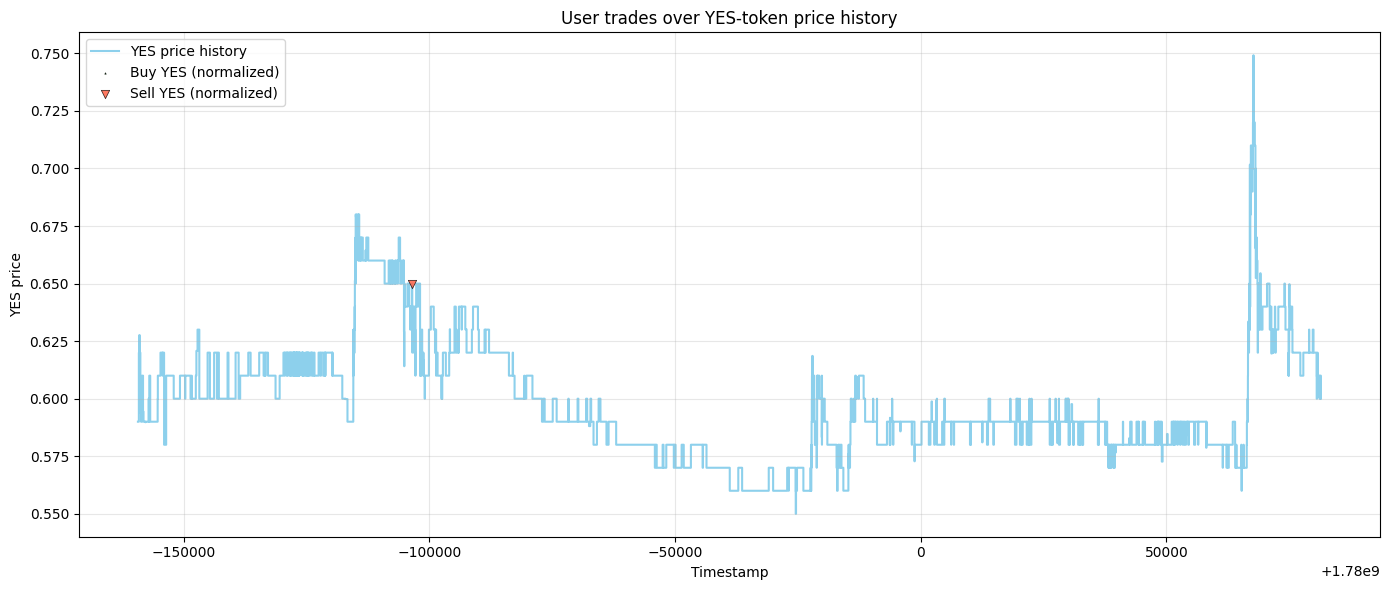

In [19]:
WALLET = '0xfaae04d9bc15dc68db0d7022677df54c3387907e'
SLUG = 'strait-of-hormuz-traffic-returns-to-normal-by-july-31'

check_candidate(WALLET, SLUG)

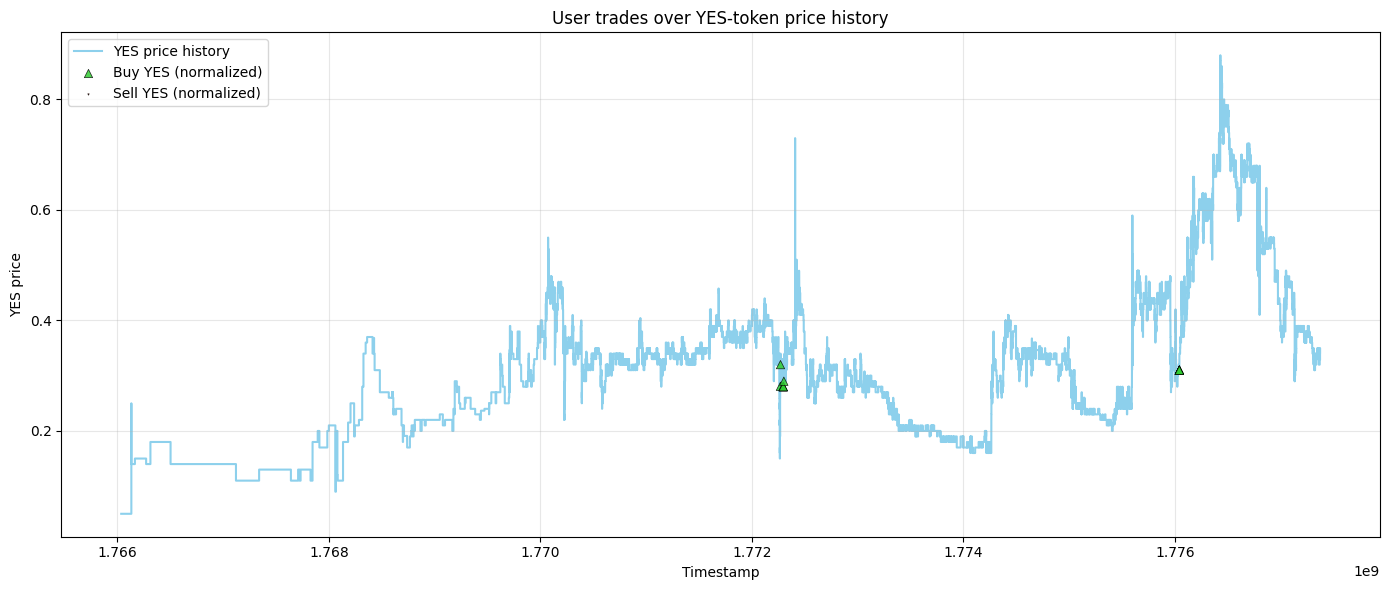

In [21]:
WALLET = '0xde7be6d489bce070a959e0cb813128ae659b5f4b'
SLUG = 'us-iran-nuclear-deal-by-june-30'

check_candidate(WALLET, SLUG)

Fetching market: will-the-us-reopen-its-embassy-in-iran-in-2026
[polycluster:will-the-us-reopen-its-embassy-in-iran-i] get_orderfilled_events: 2 token(s), window=[1772395719, 1780083201] (7687482s)
[polycluster:will-the-us-reopen-its-embassy-in-iran-i]   (1/4) token 1/2 side=maker: starting...
[polycluster:will-the-us-reopen-its-embassy-in-iran-i]     d=0 side=maker [1772395719, 1780083201] (7687482s): 407 rows in 0.34s -> done
[polycluster:will-the-us-reopen-its-embassy-in-iran-i]   (1/4) token 1/2 side=maker: 407 rows in 0.3s
[polycluster:will-the-us-reopen-its-embassy-in-iran-i]   (2/4) token 1/2 side=taker: starting...
[polycluster:will-the-us-reopen-its-embassy-in-iran-i]     d=0 side=taker [1772395719, 1780083201] (7687482s): 532 rows in 0.34s -> done
[polycluster:will-the-us-reopen-its-embassy-in-iran-i]   (2/4) token 1/2 side=taker: 532 rows in 0.3s
[polycluster:will-the-us-reopen-its-embassy-in-iran-i]   (3/4) token 2/2 side=maker: starting...
[polycluster:will-the-us-reopen-i

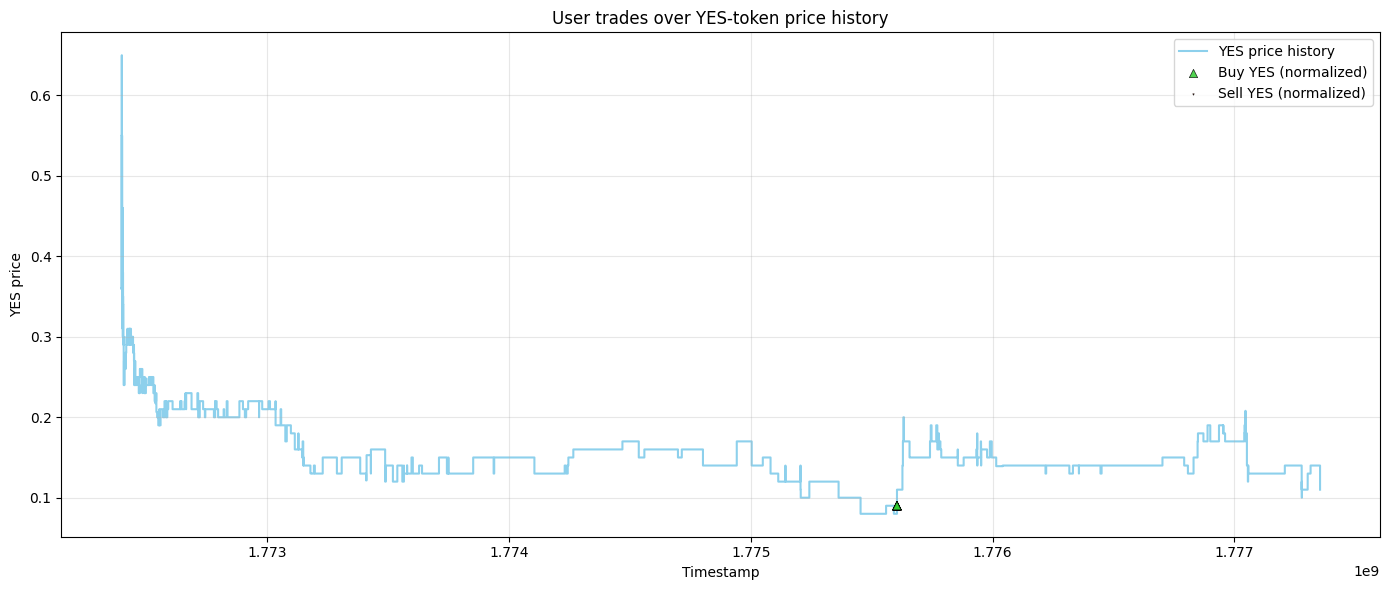

In [22]:
WALLET = '0xa465a520c557ed253b755581fa1a2abf75936b06'
SLUG = 'will-the-us-reopen-its-embassy-in-iran-in-2026'

check_candidate(WALLET, SLUG)

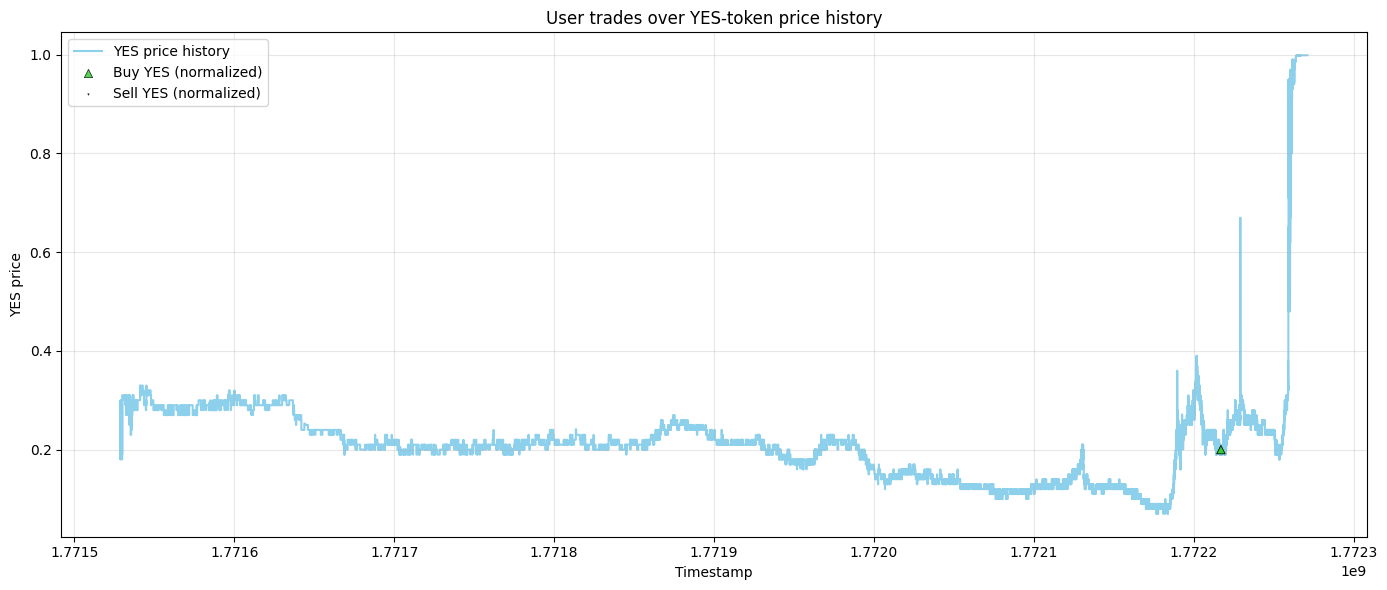

In [8]:
WALLET = '0x1b740123415b0dccff0ee15e199b3508dcb2778c'
SLUG = 'us-strikes-iran-by-march-1-2026-492'

check_candidate(WALLET, SLUG)